# run all neccessary functionalities

In [1]:


def extract_stock_data(df, tdickers, start, end):
    """
    Extract stock data for specific tickers between the start and end dates.

    Parameters:
    - df: pandas DataFrame with rows as dates (monthly) and columns as stock tickers.
    - tickers: list of tickers to extract data for.
    - start: start date (YYYY-MM-DD) for the data extraction.
    - end: end date (YYYY-MM-DD) for the data extraction.

    Returns:
    - pandas DataFrame with the specified tickers and date range.
    """
    # Ensure the date column is in datetime format
    df.index = pd.to_datetime(df.index)
    df.index=df.index.to_period('M').to_timestamp('D')
    # Filter the DataFrame for the date range
    df_filtered = df.loc[start:end]

    # Select the tickers from the DataFrame
    df_selected = df_filtered[tdickers]
    df_selected=df_selected.loc[:, df_selected.isna().sum() <= 0].dropna()
    # df_selected.interpolate(method='linear',inplace=True)
    df_selected.index = pd.to_datetime(df_selected.index)
    df_selected = df_selected.tz_localize(None)
    columns = sorted([col for col in df_selected.columns if col != 'Date'])
    df_selected=df_selected[columns]
    for col in df_selected.columns:
        try:
            df_selected[col] = df_selected[col].astype(float)
        except ValueError:
            print(f"Column '{col}' could not be converted to float.")
    df_selected.index=df_selected.index.to_period('M').to_timestamp('D')
    df_selected.replace('C', np.nan, inplace=True)
    for col in df_selected.columns:
            try:
                df_selected[col] = df_selected[col].astype(float)
            except ValueError:
                print(f"Column '{col}' could not be converted to float.")
    df_selected.interpolate(method='linear',inplace=True)
    df_selected = df_selected.fillna(method='ffill')
    df_selected = df_selected.fillna(method='bfill')
    return df_selected



In [2]:


def extract_spy_data(df, start, end):
    df.index = pd.to_datetime(df.index)
    df.index=df.index.to_period('M').to_timestamp('D')
    df_filtered = df.loc[start:end]
    return df_filtered



In [3]:
# Creates tickers ([]), monthly_data (DF), and base_w ([])
def get_spy2(start,end):
    
    ### Get tickers + setup
    global tickers,spy
    valid_tickers = []

    new_monthly_data1 = new_monthly_data.copy()
    new_monthly_data1.index = pd.to_datetime(new_monthly_data1.index)
    spy_year1 = (pd.to_datetime(start)).year
    spy_year2 = (pd.to_datetime(start) + relativedelta(years = 4)).year
    if spy_year2 >= 2025:
        spy_year2 = 2024

    subset_ticks = spy_yoy_tickers.loc[spy_year1:spy_year2]
    subset_ticks = [set(row.dropna()) for _, row in subset_ticks.iterrows()]
    tickers = set.intersection(*subset_ticks)
    for tick in tickers:
        if tick not in new_monthly_data1.columns:
            continue
        if(new_monthly_data1[tick].loc[str(spy_year1) : str(spy_year2)].isna().any()):
            continue
        valid_tickers.append(tick)
    tickers =  valid_tickers
    ### Import the monthly data
    global monthly_data
    global base_w
    monthly_data = extract_stock_data(new_monthly_data,tickers,start=start,end=end)
    
    # Assign equal weight as base weights
    base_w = {k: 1/len(monthly_data.columns) for k in monthly_data.columns}
    base_w = pd.DataFrame.from_dict(base_w, orient='index', columns=['Weight'])

    spy=extract_spy_data(indexgspc,start,end)
    if monthly_data.index.equals(spy.index)==True:
        for i,j in monthly_data.iterrows():
            monthly_data.loc[i,'SP_500']=spy.loc[i,'SP_500']
    # Adjusting tickers list as some tickers will not be included in the monthly_data if there is no data for test date range
    tickers = list(monthly_data.columns[:-1]) 


In [4]:



def download_with_retry(tickers, start, end, retries=3, delay=5):
    for attempt in range(retries):
        try:
            return extract_stock_data(new_monthly_data,tickers, start=start, end=end)
        except Exception as e:
            print(f"Attempt {attempt + 1} failed: {e}")
            time.sleep(delay)
    raise Exception(f"Failed to download data after {retries} attempts.")




In [7]:
def famafrenchreturns():
    global ff3_monthly
    # Fama French Monthly Returns Data using getFamaFrenchFactors module
    ff3_monthly = gff.famaFrench3Factor(frequency='m')
    ff3_monthly.rename(columns={"date_ff_factors": 'Date'}, inplace=True)
    ff3_monthly.set_index('Date', inplace=True)
    ff3_monthly.index = ff3_monthly.index.to_period('M').to_timestamp('D')
    # Keeping Only the Dates in the monthly_data
    ff3_monthly = ff3_monthly.loc[monthly_data.index]
    

In [8]:
def to__cal_stock_betas():
    global stock_betas
    stock_betas = pd.DataFrame()
    # Iterate over the tickers list
    for col in monthly_data.columns:
        # Set the dependent variable (Return of stock i)
        y = monthly_data[col]
        # Set the independent variables (Fama French 3 Factors)
        X = ff3_monthly[['Mkt-RF','SMB','HML']]
        # Fit the multiple linear regression model
        model = LinearRegression()
        model.fit(X, y)
        # Store the results in the DataFrame
        stock_betas[col] = [model.intercept_] + list(model.coef_)
    stock_betas = stock_betas.T
    stock_betas.columns = ['Intercept','Mkt-RF','SMB','HML']

In [9]:
def to_cal_stock_price(startt,endd):
    global stock_price
    global s_price
    global s_keys
    global s_values
    #Stock Prices on the Day of Optimization(Rebalancing)
    stock_price = extract_stock_data(price_monthly_data,tickers,start=startt,end=endd)
    stock_price = stock_price[-1:]
    stock_price.index = pd.to_datetime(stock_price.index).tz_localize(None)
    s_price = {}
    s_keys = list(tickers)
    s_values =  list(stock_price.iloc[0])
    for key,value in zip(s_keys,s_values):
        s_price[key] = value

In [10]:
def Transaction_Costs(initialize=False):
    # if initialize:
    #     print("first draw:", np.random.random())

    global t_cost
    t_cost = {}
    global keys
    keys = list(tickers)
    values = list(random.uniform(.01, .02) for i in range(len(tickers)))
    for key, value in zip(keys, values):
        t_cost[key] = value


In [11]:
def optimization():
    new_seed = np.random.randint(0, 1_000_000_000, dtype=int)
    np.random.seed(new_seed)      # legacy code path inside optimizer
    random.seed(new_seed) 
# OPTIMIZATION MODEL
    global index
    global wei
    global aux
    global err
    global binary
    global tr_cost
    global shares
    index = LpProblem('Index', LpMinimize) 
    # Decision Variables
    wei = LpVariable.dicts('Weight',tickers,lowBound=0)                           # Weights for stock i in the optimal portfolio
    aux = LpVariable.dicts('Y',tickers,lowBound=0)                                # Absolute value of change for stock i from base weights
    err = LpVariable.dicts('Error', monthly_data.index, lowBound=0)               # Error term for portfolio
    binary = LpVariable.dicts('bin',tickers,cat=LpBinary)                         # Used if we want to limit the # of stocks we want to have in optimal portfolio
    tr_cost = LpVariable.dicts('Transaction_Cost',tickers,lowBound=0)             # Total Transaction cost for stock i in the optimal portfolio
    shares = LpVariable.dicts('shares',tickers,lowBound=0)                        # Total Transaction cost for stock i in the optimal portfolio
    #Objective Function - Minimize the error term 
    index +=  lpSum(err[t] for t in monthly_data.index) # Constraint: Weights sum to 1 
    index += lpSum(wei[i] for i in tickers) == 1
    # Constraint: Absolute value of change in weights from base weigths
    for i in tickers:
        index += aux[i] >= base_weights[i]  - wei[i]
        index += aux[i] >= wei[i] - base_weights[i]
    index += lpSum(aux[i] for i in tickers) <= 1 
    # Constraint: Error term
    for t in monthly_data.index:
        index += lpSum(wei[i]*(monthly_data.loc[t,i]-ff3_monthly.loc[t,'RF']) for i in tickers) - err[t] <= (mkt_opt*ff3_monthly.loc[t,'Mkt-RF']+smb_opt*ff3_monthly.loc[t,'SMB']+hml_opt*ff3_monthly.loc[t,'HML'])
        index += lpSum(wei[i]*(monthly_data.loc[t,i]-ff3_monthly.loc[t,'RF']) for i in tickers) + err[t] >= (mkt_opt*ff3_monthly.loc[t,'Mkt-RF']+smb_opt*ff3_monthly.loc[t,'SMB']+hml_opt*ff3_monthly.loc[t,'HML'])
    # Shares
    for i in tickers:
        index += shares[i] == (aux[i]*B/s_price[i])
    # Transaction Costs
    for i in tickers:
        index += lpSum(aux[i] *B*t_cost[i]/s_price[i]) == tr_cost[i]
    index += lpSum(tr_cost[i] for i in tickers) <= 2000
    # Limit # of stocks in Optimal Portfolio
    for i in tickers: # Forces weight of stock i to be less than binary value of stock i. If stock is not selected binary variable is 0 which then forces weight of stock i to be in the optimal portfolio to be 0.
        index += wei[i] <= binary[i]
    index += lpSum(binary[i] for i in tickers) <= q
    index.solve()
    

In [12]:
def others():
    global sharess
    #Change in number of shares
    sharess = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 's'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 's'] , columns = ['Optimal'])
    sharess
    global tr_cost
    #Transaction Costs
    tr_cost = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 'T'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 'T'] , columns = ['Optimal'])
    tr_cost.sum()
    global weii
    #Optimal weights
    weii = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 'W'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 'W'] , columns = ['Optimal'])
    weii.sum()
    global auxx
    #Change of weights
    auxx = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 'Y'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 'Y'] , columns = ['Optimal'])
    auxx.sum()
    global errr
    #Error terms
    errr = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 'E'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 'E'] , columns = ['Optimal'])
    errr.sum()
    global binary_v
    # Check if Binary Values Constraint works
    binary_v = pd.DataFrame([v.varValue for v in index.variables() if v.varValue != 0 and str(v.name)[0] == 'b'], index = [str(v.name) for v in index.variables() if v.varValue != 0 and str(v.name)[0] == 'b'] , columns = ['Optimal'])
    binary_v.sum()
    global opt_weights 
    # Weights in Optimal Portfolio
    opt_weights = pd.DataFrame([v.varValue for v in index.variables() if v.varValue != 0 and str(v.name)[0] == 'W'], index = [str(v.name) for v in index.variables() if v.varValue != 0 and str(v.name)[0] == 'W'] , columns = ['Optimal'])
    opt_weights.style.format('{:,.2%}'.format)
    global weights_new
    weights_new = pd.DataFrame([v.varValue for v in index.variables() if str(v.name[0]) == 'W'], index = [str(v.name).split('_')[1] for v in index.variables() if str(v.name[0]) == 'W'] , columns = ['New Weights'])
    global weights
    weights = pd.DataFrame(np.zeros((len(monthly_data.columns[:-1]),3)), index=monthly_data.columns[:-1], columns=['PORTFOLIO Weights','Difference','New Weights'])
    for t in monthly_data.columns[:-1]:
        weights.loc[t][0] = base_w.loc[t]
        weights.loc[t][1] = weights_new.loc[t][0]-base_w.loc[t][0]
        weights.loc[t][2] = weights_new.loc[t]
    weights
    columns_to_remove = ['PORTFOLIO Weights', 'Difference']
    # Specify the column to filter non-zero values
    column_to_filter = 'New Weights'
    # Create a new DataFrame with selected columns and rows where New Weights is not equal to 0
    global opt_portf_weights
    opt_portf_weights = weights.drop(columns=columns_to_remove)[weights[column_to_filter] != 0]




In [13]:
def portfolio_betas():
    # CHECK PORTFOLIO BETAS
   
    global port_betas
    port_returns = pd.DataFrame(np.zeros((len(monthly_data.index),2)), index=monthly_data.index, columns=["SP_500","Optimization"])
    for j in port_returns.index:
        port_returns.loc[j]["SP_500"] = monthly_data.loc[j]['SP_500']
        port_returns.loc[j]['Optimization'] = monthly_data.loc[j,:monthly_data.columns[-2]].dot(weights['New Weights'])
    port_returns = port_returns.merge(ff3_monthly[['Mkt-RF','SMB','HML']], left_index=True, right_index=True)
    # Create an empty DataFrame to store the Portfolio Beta
    port_betas = pd.DataFrame(np.zeros((3,4)), index=ff3_monthly.columns[0:3], columns=["SP_500", "Target", "Optimization", "Abs. Diff"])
    port_betas["Target"] = [mkt_opt, smb_opt, hml_opt]# Set the independent variables (Fama French 3 Factors)
    X = port_returns[['Mkt-RF','SMB','HML']]
    # Set the dependent variable (Return of Portfolio)
    Y = port_returns['SP_500']# Fit the multiple linear regression model
    regr = LinearRegression()
    regr.fit(X,Y)
    port_betas['SP_500'] = regr.coef_
    # Set the dependent variable (Return of Portfolio)
    Y = port_returns['Optimization']
    # Fit the multiple linear regression model
    regr = LinearRegression()
    regr.fit(X,Y)
    port_betas['Optimization'] = regr.coef_
    # Abs Difference between Target Betas & Optimal Portfolio Betas
    port_betas["Abs. Diff"] = round(abs(port_betas['Optimization'] - port_betas["Target"]),4)
    port_betas
    return port_betas
    

In [14]:
def simulator(beta1,beta2,beta3,begin,final,budget,number):
    global start
    global end
    start=begin
    end=final
    
    get_spy2(start,end)
    #Adjusting tickers list as some tickers will not be included in the monthly_data if there is no data for test date range
    global tickers
    tickers = list(monthly_data.columns[:-1])
    tick_index = tickers + ['SP_500']
    

    # TARGET FACTOR BETAS 
    global base_weights
    global mkt_opt
    global smb_opt
    global hml_opt
    global B
    global q
    
    mkt_opt = beta1                          # TARGET MKT BETA - EXPOSURE OF THE NEW PORTFOLIO TO MARKET FACTOR 
    smb_opt = beta2                           # TARGET SMB BETA - EXPOSURE OF THE NEW PORTFOLIO TO SIZE FACTOR 
    hml_opt = beta3                           # TARGET HML BETA - EXPOSURE OF THE NEW PORTFOLIO TO VALUE FACTOR 
    B = budget                             # BUDGET
    q = number                                # NUMBER OF STOCKS IN THE NEW PORTFOLIO
    base_weights = base_w.T*0               # ONLY HAVE THIS LINE OF CODE WHEN YOU ARE CONSTRUCTING THE PORTFOLIO FROM SCRATCH 
    
    famafrenchreturns()
    to__cal_stock_betas()
    to_cal_stock_price(start,end)
    Transaction_Costs()
    optimization()
    others()
    portfolio_betas()
    opt_portf_weights
    global port_betas
    opt_portf_weights


In [15]:
def out_of_sampless(cccc,dddd):
    global oos1_daily_data
    global oos1_spy_d
    global oos1_new_performance
    global o1_end_d
    global o1_start_d
    o1_start_d = cccc
    o1_end_d   = dddd
    oos1_daily_data = extract_stock_data(new_monthly_data,opt_portf_weights.index.tolist(),start=o1_start_d,end=o1_end_d)
    # oos1_daily_data = oos1_daily_data['Adj Close'].pct_change().dropna()
    oos1_daily_data = oos1_daily_data.tz_localize(None)
    oos1_spy_d=extract_spy_data(indexgspc,cccc,dddd)
    # oos1_spy_d = pd.DataFrame(yf.download('^GSPC',start=o1_start_d,end=o1_end_d,interval='1mo')['Adj Close'].pct_change())
    # oos1_spy_d = oos1_spy_d.drop(oos1_spy_d.index[0]).tz_localize(None)
    oos1_daily_data['SP_500'] = oos1_spy_d['SP_500']
    oos1_daily_data['Optimized Portfolio'] = ''
    for i in range(len(oos1_daily_data.index)):
        oos1_daily_data.iloc[i,-1] = oos1_daily_data.iloc[i,:-2].dot(opt_portf_weights['New Weights'])
    oos1_daily_data=oos1_daily_data.dropna()
    init = 1        #Initial Common Value (Can be thought of Initial Investment of $1 USD in each stock)
    oos1_new_returns = pd.DataFrame(np.ones((len(oos1_daily_data),len(oos1_daily_data.columns))), index = oos1_daily_data.index, columns = oos1_daily_data.columns)
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_returns.iloc[j] = oos1_new_returns.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns])
    oos1_new_performance = pd.DataFrame(np.ones((len(oos1_daily_data),2)), index = oos1_daily_data.index, columns = oos1_daily_data.columns[-2:])
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_performance.iloc[j] = oos1_new_performance.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns[-2:]]+1)
    
    return oos1_new_performance

In [16]:
def out_of_sample():
    global oos1_daily_data
    global oos1_spy_d
    global oos1_new_performance
    global o1_end_d
    global o1_start_d
    o1_start_d = os_start
    o1_end_d   = os_end
    oos1_daily_data = extract_stock_data(new_monthly_data,opt_portf_weights.index.tolist(),start=o1_start_d,end=o1_end_d)
    oos1_daily_data = oos1_daily_data.tz_localize(None)
    oos1_spy_d=extract_spy_data(indexgspc,os_start,os_end)
    oos1_daily_data['SP_500'] = oos1_spy_d['SP_500']
    oos1_daily_data['Optimized Portfolio'] = ''
    for i in range(len(oos1_daily_data.index)):
        oos1_daily_data.iloc[i,-1] = oos1_daily_data.iloc[i,:-2].dot(opt_portf_weights['New Weights'])
    oos1_daily_data=oos1_daily_data.dropna()
    oos1_new_returns = pd.DataFrame(np.ones((len(oos1_daily_data),len(oos1_daily_data.columns))), index = oos1_daily_data.index, columns = oos1_daily_data.columns)
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_returns.iloc[j] = oos1_new_returns.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns])
    oos1_new_performance = pd.DataFrame(np.ones((len(oos1_daily_data),2)), index = oos1_daily_data.index, columns = oos1_daily_data.columns[-2:])
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_performance.iloc[j] = oos1_new_performance.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns[-2:]]+1)
    return oos1_new_performance

In [17]:
def out_of_sample():
    global oos1_daily_data,oos1_new_returns
    global oos1_new_performance
    global o1_end_d
    global o1_start_d
    o1_start_d = os_start
    o1_end_d   = os_end
    oos1_daily_data = extract_stock_data(new_monthly_data,opt_portf_weights.index.tolist(),start=o1_start_d,end=o1_end_d)
    oos1_daily_data = oos1_daily_data.tz_localize(None)
    oos1_spy_d=extract_spy_data(indexgspc,os_start,os_end)
    oos1_daily_data['SP_500'] = oos1_spy_d['SP_500']
    oos1_daily_data['Optimized Portfolio'] = ''
    for i in range(len(oos1_daily_data.index)):
        oos1_daily_data.iloc[i,-1] = oos1_daily_data.iloc[i,:-2].dot(opt_portf_weights['New Weights'])
    oos1_daily_data=oos1_daily_data.dropna()
    init = 1        #Initial Common Value (Can be thought of Initial Investment of $1 USD in each stock)
    oos1_new_returns = pd.DataFrame(np.ones((len(oos1_daily_data),len(oos1_daily_data.columns))), index = oos1_daily_data.index, columns = oos1_daily_data.columns)
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_returns.iloc[j] = oos1_new_returns.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns])
    oos1_new_performance = pd.DataFrame(np.ones((len(oos1_daily_data),2)), index = oos1_daily_data.index, columns = oos1_daily_data.columns[-2:])
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_performance.iloc[j] = oos1_new_performance.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns[-2:]]+1)
    
    return oos1_new_performance

In [18]:
def new_mod_out_of_sample1(hsahs,hsahs2):
    global oos1_daily_data
    global oos1_spy_d
    global oos1_new_performance
    global o1_start_d
    global o1_end_d
    o1_start_d = hsahs
    # last_key = list(out_of_sample_year_end.keys())[-1]
    o1_end_d   = hsahs2
    oos1_daily_data = extract_stock_data(new_monthly_data,opt_portf_weights.index.tolist(),start=o1_start_d,end=o1_end_d)
    # oos1_daily_data = oos1_daily_data['Adj Close'].pct_change().dropna()
    oos1_daily_data = oos1_daily_data.tz_localize(None)
    # oos1_spy_d = pd.DataFrame(yf.download('^GSPC',start=o1_start_d,end=o1_end_d,interval='1mo')['Adj Close'].pct_change())
    oos1_spy_d=extract_spy_data(indexgspc,o1_start_d,o1_end_d)
    oos1_spy_d = oos1_spy_d.drop(oos1_spy_d.index[0]).tz_localize(None)
    oos1_daily_data['SP_500'] = oos1_spy_d['SP_500']
    oos1_daily_data['Optimized Portfolio'] = ''
    for i in range(len(oos1_daily_data.index)):
        oos1_daily_data.iloc[i,-1] = oos1_daily_data.iloc[i,:-2].dot(opt_portf_weights['New Weights'])
    oos1_daily_data
    oos1_daily_data=oos1_daily_data.dropna()
    oos1_new_returns = pd.DataFrame(np.ones((len(oos1_daily_data),len(oos1_daily_data.columns))), index = oos1_daily_data.index, columns = oos1_daily_data.columns)
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_returns.iloc[j] = oos1_new_returns.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns])
    oos1_new_performance = pd.DataFrame(np.ones((len(oos1_daily_data),2)), index = oos1_daily_data.index, columns = oos1_daily_data.columns[-2:])
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_performance.iloc[j] = oos1_new_performance.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns[-2:]]+1)
    
    return oos1_new_performance

In [19]:
def mod_out_of_sample1():
    global oos1_daily_data
    global oos1_spy_d
    global oos1_new_performance
    global o1_start_d
    global o1_end_d
    o1_start_d = out_of_sample_year_start[1]
    last_key = list(out_of_sample_year_end.keys())[-1]
    o1_end_d   = out_of_sample_year_end[last_key]
    oos1_daily_data = extract_stock_data(new_monthly_data,opt_portf_weights.index.tolist(),start=o1_start_d,end=o1_end_d)
    # oos1_daily_data = oos1_daily_data['Adj Close'].pct_change().dropna()
    oos1_daily_data = oos1_daily_data.tz_localize(None)
    oos1_spy_d=extract_spy_data(indexgspc,o1_start_d,o1_end_d)
    oos1_spy_d = oos1_spy_d.drop(oos1_spy_d.index[0]).tz_localize(None)
    oos1_daily_data['SP_500'] = oos1_spy_d['SP_500']
    oos1_daily_data['Optimized Portfolio'] = ''
    for i in range(len(oos1_daily_data.index)):
        oos1_daily_data.iloc[i,-1] = oos1_daily_data.iloc[i,:-2].dot(opt_portf_weights['New Weights'])
    oos1_daily_data
    oos1_daily_data=oos1_daily_data.dropna()
    oos1_new_returns = pd.DataFrame(np.ones((len(oos1_daily_data),len(oos1_daily_data.columns))), index = oos1_daily_data.index, columns = oos1_daily_data.columns)
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_returns.iloc[j] = oos1_new_returns.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns])
    oos1_new_performance = pd.DataFrame(np.ones((len(oos1_daily_data),2)), index = oos1_daily_data.index, columns = oos1_daily_data.columns[-2:])
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_performance.iloc[j] = oos1_new_performance.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns[-2:]]+1)
    
    return oos1_new_performance

In [20]:
def mod_out_of_sample():
    global oos1_daily_data
    global oos1_new_performance
    o1_start_d = os_start
    o1_end_d   = os_end
    oos1_daily_data = extract_stock_data(new_monthly_data,opt_portf_weights.index.tolist(),start=o1_start_d,end=o1_end_d)
    # oos1_daily_data = oos1_daily_data['Adj Close'].pct_change().dropna()
    oos1_daily_data = oos1_daily_data.tz_localize(None)
    # oos1_spy_d = pd.DataFrame(yf.download('^GSPC',start=o1_start_d,end=o1_end_d,interval='1mo')['Adj Close'].pct_change())
    oos1_spy_d=extract_spy_data(indexgspc,o1_start_d,o1_end_d)
    oos1_spy_d = oos1_spy_d.drop(oos1_spy_d.index[0]).tz_localize(None)
    oos1_daily_data['SP_500'] = oos1_spy_d['SP_500']
    oos1_daily_data['Optimized Portfolio'] = ''
    for i in range(len(oos1_daily_data.index)):
        oos1_daily_data.iloc[i,-1] = oos1_daily_data.iloc[i,:-2].dot(opt_portf_weights['New Weights'])
    oos1_daily_data
    oos1_daily_data=oos1_daily_data.dropna()
    oos1_new_returns = pd.DataFrame(np.ones((len(oos1_daily_data),len(oos1_daily_data.columns))), index = oos1_daily_data.index, columns = oos1_daily_data.columns)
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_returns.iloc[j] = oos1_new_returns.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns])
    oos1_new_performance = pd.DataFrame(np.ones((len(oos1_daily_data),2)), index = oos1_daily_data.index, columns = oos1_daily_data.columns[-2:])
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_performance.iloc[j] = oos1_new_performance.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns[-2:]]+1)
    
    return oos1_new_performance

In [22]:
def current_date():
    global today
    global os_start
    global os_end
    global n_year_before
    global n_year_after
    from datetime import datetime, timedelta
    today = datetime.today()
    one_year_before = today - timedelta(days=365)
    os_start = today - timedelta(days=365)
    two_months_before = os_start - timedelta(days=2*30)
    os_start = two_months_before.replace(day=1)
    one_month_before = today - timedelta(days=30)
    os_end = one_month_before.replace(day=1)
    
    n_year_before = os_start - timedelta(days=(365*n_years))
    n_year_after=n_year_before+timedelta(days=(365*n_years))                           
    os_start=os_start.strftime("%Y-%m-%d")
    os_end=os_end.strftime("%Y-%m-%d")
    n_year_before=n_year_before.strftime("%Y-%m-%d")
    n_year_after=n_year_after.strftime("%Y-%m-%d")
    from datetime import date

    today = date.today()
    formatted_date = today.strftime("%Y-%m-%d")
    today = formatted_date


In [23]:
def new_date_calculation():
    from datetime import datetime, timedelta
    from datetime import date
    today = datetime.now()
    global out_of_sample_year_start
    global out_of_sample_year_end
    out_of_sample_year_start={}
    out_of_sample_year_end={}
    for year in range(os_years):
        out_of_sample_year_start[(year+1)] = today - timedelta(days=(365 * (os_years - year)))
        two_months_before = (out_of_sample_year_start[(year+1)] - relativedelta(months = today.month- 1))
        out_of_sample_year_start[(year+1)] = two_months_before.replace(day=1)
        years=out_of_sample_year_start[(year+1)].year
        if (years % 4 == 0 and years % 100 != 0) or (years % 400 == 0):
            is_leap_year = True
            no_days_in_year = 366
        else:
            is_leap_year = False
            no_days_in_year = 365
        out_of_sample_year_end[(year+1)]=out_of_sample_year_start[(year+1)]+ timedelta(days=no_days_in_year-1)
        out_of_sample_year_start[(year+1)]=out_of_sample_year_start[(year+1)].strftime("%Y-%m-%d")
        out_of_sample_year_end[(year+1)]=out_of_sample_year_end[(year+1)].strftime("%Y-%m-%d")                        
    
    global in_of_sample_year_start
    in_of_sample_year_start={}
    global in_of_sample_year_end
    in_of_sample_year_end={}
    for year in range(in_years):
        in_of_sample_year_start[(year+1)] = today - timedelta(days=(365 * ((in_years+os_years) - year)))
        two_months_before = in_of_sample_year_start[(year+1)] - relativedelta(months = today.month-1)
        in_of_sample_year_start[(year+1)] = two_months_before.replace(day=1)
        years=in_of_sample_year_start[(year+1)].year
        if (years % 4 == 0 and years % 100 != 0) or (years % 400 == 0):
            is_leap_year = True
            no_days_in_year = 366
        else:
            is_leap_year = False
            no_days_in_year = 365
        in_of_sample_year_end[(year+1)]=in_of_sample_year_start[(year+1)]+ timedelta(days=no_days_in_year-1)
        in_of_sample_year_start[(year+1)]=in_of_sample_year_start[(year+1)].strftime("%Y-%m-%d")
        in_of_sample_year_end[(year+1)]=in_of_sample_year_end[(year+1)].strftime("%Y-%m-%d")
    
    inner_in_of_sample_year_start={}
    for year in range(in_years+os_years):
        inner_in_of_sample_year_start[(year+1)] = today - timedelta(days=(365 * (in_years+os_years - year)))
        two_months_before = inner_in_of_sample_year_start[(year+1)] - relativedelta(months = today.month-1)
        inner_in_of_sample_year_start[(year+1)] = two_months_before.replace(day=1)
        years=inner_in_of_sample_year_start[(year+1)].year
        if (years % 4 == 0 and years % 100 != 0) or (years % 400 == 0):
            is_leap_year = True
            no_days_in_year = 366
        else:
            is_leap_year = False
            no_days_in_year = 365
        inner_in_of_sample_year_start[(year+1)]=inner_in_of_sample_year_start[(year+1)].strftime("%Y-%m-%d")
        

    today = date.today()
    formatted_date = today.strftime("%Y-%m-%d")
    today = formatted_date
    return inner_in_of_sample_year_start

In [24]:
def new_run_with_backtest_rebalance(inyears,outyears,betaA,betaB,betaC, rebal_freq):
    global start_date
    global end_date
    global os_years,tostorelist,nchecklist
    global in_years
    os_years=outyears
    in_years=inyears
    global performances
    performances={}
    global spy_performances
    spy_performances={}
    global new_performances
    new_performances={}
    global new_spy_performances
    new_spy_performances={}
    global inner_n_year_before_cal
    inner_n_year_before_cal=new_date_calculation()
    global n_year_before
    global n_year_after
    n_year_before=in_of_sample_year_start[1]
    n_year_after=in_of_sample_year_end[in_years]
    global newbudget
    newbudget = 1000000
    simulator(betaA,betaB,betaC,n_year_before,n_year_after,newbudget,500)
    global checklist
    global mchecklist
    checklist=[]
    mchecklist=[]
    tostorelist=[]
    global rebalance_opt_weights
    global port_betas_list 
    port_betas_list = []
    rebalance_opt_weights = []
    os_count = 1        
    for k in range(os_years): 
        global os_start
        global os_end
        global oos1_new_performances 
        oos1_new_performances={}
        global init
        os_start=out_of_sample_year_start[1+k]
        os_end=out_of_sample_year_end[1+k]

        noos1_new_performance=pd.DataFrame()
        global checklist_1
        new_date_calculation()
        
        checking=out_of_sample()
        tostorelist.append(checking)
        inner_n_year_before=inner_n_year_before_cal[k+2]
        inner_n_year_after=out_of_sample_year_end[1+k]
        checklist.append(oos1_new_performance)
        
        if(rebal_freq == 'y'):
            newbudget=1000000*oos1_new_performance['Optimized Portfolio'][-1]
            simulator(betaA,betaB,betaC,inner_n_year_before,inner_n_year_after,newbudget,500)
            rebalance_opt_weights.append(opt_weights)
            if(os_count == os_years):
                checklist=extract_performance(checklist)
                noos1_new_performance=pd.concat(checklist, ignore_index=False)
        if rebal_freq == 'dry':
            newbudget=1000000*oos1_new_performance['Optimized Portfolio'][-1]
            curr_year = pd.to_datetime(inner_n_year_after).year
            try:
                curr_df = pd.read_csv(f'explored_sortino{curr_year}.csv')
            except:
                print('File DNE')
            curr_df = curr_df.sort_values(by='reward')
            betaA = curr_df.iloc[-1][0]
            betaB = curr_df.iloc[-1][1]
            betaC = curr_df.iloc[-1][2]
            print(f'{betaA}, {betaB}, {betaC} ')
            simulator(betaA,betaB,betaC,inner_n_year_before,inner_n_year_after,newbudget,500)
            rebalance_opt_weights.append(opt_weights)
            if(os_count == os_years):
                checklist=extract_performance(checklist)
                noos1_new_performance=pd.concat(checklist, ignore_index=False)
        if k == 0:
            performances[k + 1] = oos1_new_performance["Optimized Portfolio"].iloc[-1]
            spy_performances[k + 1] = oos1_new_performance["SP_500"].iloc[-1]
            start_date = os_start
        else:
            performances[k + 1] = oos1_new_performance["Optimized Portfolio"].iloc[-1] * performances[k]
            spy_performances[k + 1] = oos1_new_performance["SP_500"].iloc[-1] * spy_performances[k]
            end_date = os_end 
        os_count +=1
    for kk in range(os_years): 
        placeholder=noos1_new_performance.index[0]
        placeholder=placeholder.replace(year=placeholder.year+(kk+1))
        if placeholder in noos1_new_performance.index:
            new_spy_performances[kk + 1] = noos1_new_performance.loc[placeholder,"SP_500"]
            new_performances[kk + 1] = noos1_new_performance.loc[placeholder,"Optimized Portfolio"]
    
    new_spy_performances[os_years] = noos1_new_performance.iloc[-1].loc["SP_500"]
    new_performances[os_years] = noos1_new_performance.iloc[-1].loc["Optimized Portfolio"]
    return noos1_new_performance 
    
            
            
        

In [ ]:
def new_run_with_backtest_mrebalance(inyears,outyears,betaA,betaB,betaC, rebal_freq):
    global os_years
    global in_years
    global os_months
    os_years=outyears
    os_months = os_years*12
    in_years=inyears
    global performances
    performances={}
    global spy_performances
    spy_performances={}
    global new_performances
    new_performances={}
    global new_spy_performances
    new_spy_performances={}
    new_date_calculation()
    global n_year_before
    global n_year_after
    n_year_before= in_of_sample_year_start[1]
    n_year_after= in_of_sample_year_end[in_years]

    #so base is above, and then first step is to grab the performance of January 2020 (assuming standard run)
    #to add to noos1_perf and to update budget    

    global rebalance_opt_weights
    global port_betas_list 
    port_betas_list = []
    rebalance_opt_weights = []
    prev_month_perf = 1
    noos1_new_performance=pd.DataFrame()
    
    for k in range(os_months-1): 
        # so base is above, and then first step is to grab the performance of January 2020 (assuming standard run)
        # to add to noos1_perf and to update budget    
        if(rebal_freq == 'm'):
            n_year_before_updated = str(pd.to_datetime(n_year_before) + relativedelta(months=k))
            n_year_after_updated = str(pd.to_datetime(n_year_after) + relativedelta(months=k))
            simulator(betaA,betaB,betaC,n_year_before_updated,n_year_after_updated,1000000*prev_month_perf,50)


            start_date = str(pd.to_datetime(n_year_after_updated) + relativedelta(months=0))
            end_date = str(pd.to_datetime(n_year_after_updated) + relativedelta(months=2))
            
            mperformance = out_of_sampless(start_date,end_date).copy()
            snipped_perf = mperformance.iloc[1]
            if(k==0):
                first_perf = mperformance.iloc[0]
                noos1_new_performance = pd.concat([noos1_new_performance , first_perf.to_frame().T])
            prev_month_perf = snipped_perf['Optimized Portfolio'] * prev_month_perf
            noos1_new_performance = pd.concat([noos1_new_performance , snipped_perf.to_frame().T])
        if(rebal_freq == 'drm'):
            n_year_before_updated = str(pd.to_datetime(n_year_before) + relativedelta(months=k))
            n_year_after_updated = str(pd.to_datetime(n_year_after) + relativedelta(months=k))
            print()
            curr_year = (pd.to_datetime(n_year_after_updated)+relativedelta(months=1)).year 
            print(pd.to_datetime(n_year_after_updated)+relativedelta(months=1))
            try:
                curr_df = pd.read_csv(f'explored_sortino{curr_year}.csv')            
            except:
                print('File DNE')
            curr_df = curr_df.sort_values(by='reward')
            betaA = curr_df.iloc[-1][0]
            betaB = curr_df.iloc[-1][1]
            betaC = curr_df.iloc[-1][2]
        
            print(f'{betaA}, {betaB}, {betaC} ')
            simulator(betaA,betaB,betaC,n_year_before_updated,n_year_after_updated,1000000*prev_month_perf,50)


            start_date = str(pd.to_datetime(n_year_after_updated) + relativedelta(months=0))
            end_date = str(pd.to_datetime(n_year_after_updated) + relativedelta(months=2))
            
            mperformance = out_of_sampless(start_date,end_date).copy()
            snipped_perf = mperformance.iloc[1]
            if(k==0):
                first_perf = mperformance.iloc[0]
                noos1_new_performance = pd.concat([noos1_new_performance , first_perf.to_frame().T])
            prev_month_perf = snipped_perf['Optimized Portfolio'] * prev_month_perf
            noos1_new_performance = pd.concat([noos1_new_performance , snipped_perf.to_frame().T])
    noos1_new_performance = extract_performance_monthly(noos1_new_performance)
        
    return noos1_new_performance 
    
        
        

In [28]:
def extract_performance_monthly(dflist):
    global monthly_returns
    dflist.index.name = 'Date'
    monthly_returns = dflist.astype(float)
    roi = monthly_returns.cumprod()
    roi.index.name='Date'
    return roi


In [29]:
def extract_performance(dflist):
    size=len(dflist)
    for i in range(size):
        eoy_performance=dflist[i]['Optimized Portfolio'][-1]
        eoy_spy=dflist[i]['SP_500'][-1]
        if i<(size-1):
            dflist[i+1]['Optimized Portfolio']=dflist[i+1]['Optimized Portfolio']*eoy_performance
            dflist[i+1]['SP_500']=dflist[i+1]['SP_500']*eoy_spy
    dflist[1]=dflist[1].iloc[1:]
    return dflist
            

In [30]:
def new_run_with_backtest(inyears,outyears,betaA,betaB,betaC):
    
    global os_years
    global in_years
    os_years=outyears
    in_years=inyears
    global performances
    performances={}
    global spy_performances
    spy_performances={}
    global new_performances
    new_performances={}
    global new_spy_performances
    new_spy_performances={}
    new_date_calculation()
    global n_year_before
    global n_year_after
    n_year_before= in_of_sample_year_start[1]
    n_year_after= in_of_sample_year_end[in_years]
    
    simulator(betaA,betaB,betaC,n_year_before,n_year_after,1000000,50)
    global checklist
    checklist=[]
    for k in range(os_years): 
        global os_start
        global os_end
        global oos1_new_performances
        oos1_new_performances={}
        global init
        os_start=out_of_sample_year_start[1+k]
        os_end=out_of_sample_year_end[1+k]
        out_of_sample()
        
        checklist.append(oos1_new_performance)
        if k == 0:
            performances[k + 1] = oos1_new_performance["Optimized Portfolio"].iloc[-1]
            spy_performances[k + 1] = oos1_new_performance["SP_500"].iloc[-1]
        else:
            performances[k + 1] = oos1_new_performance["Optimized Portfolio"].iloc[-1] * performances[k]
            spy_performances[k + 1] = oos1_new_performance["SP_500"].iloc[-1] * spy_performances[k]
    mod_out_of_sample1()
    for kk in range(os_years): 
        placeholder=oos1_new_performance.index[0]
        placeholder=placeholder.replace(year=placeholder.year+(kk+1))
        if placeholder in oos1_new_performance.index:
            new_spy_performances[kk + 1] = oos1_new_performance.loc[placeholder,"SP_500"]
            new_performances[kk + 1] = oos1_new_performance.loc[placeholder,"Optimized Portfolio"]
    
    new_spy_performances[os_years] = oos1_new_performance.iloc[-1].loc["SP_500"]
    new_performances[os_years] = oos1_new_performance.iloc[-1].loc["Optimized Portfolio"]
    return oos1_new_performance

In [31]:
def list_sharpe_ratio(dflist):
    i=0
    sharpe_list=[]
    for df in dflist:
        if i==0:
            checkff3_monthly = gff.famaFrench3Factor(frequency='m')
            checkff3_monthly
            checkff3_monthly.rename(columns={"date_ff_factors": 'Date'}, inplace=True)
            checkff3_monthly.set_index('Date', inplace=True)
            checkff3_monthly.index = checkff3_monthly.index.to_period('M').to_timestamp('D')
            checkff3_monthly=checkff3_monthly[checkff3_monthly.index >= df.index[0]]
            checkff3_monthly=checkff3_monthly[checkff3_monthly.index <= df.index[-1]]
            checkff3_monthly.drop(columns={'Mkt-RF','SMB','HML'},inplace=True)
            some_df2=df.copy()
            some_df2.drop(columns={'Optimized Portfolio'},inplace=True)
            sp500_sharpe_ratio=calculate_sharpe_ratio(some_df2,checkff3_monthly,'SP_500')
        i+=1
        some_df=df.copy()
        some_df.drop(columns={'SP_500'},inplace=True)
        df_sharpe_ratio=calculate_sharpe_ratio(some_df,checkff3_monthly,'Optimized Portfolio')
        sharpe_list.append(df_sharpe_ratio.copy())
    sharpe_list = pd.DataFrame(sharpe_list)
    sharpe_average=sharpe_list.mean()
    return sharpe_average,sharpe_list,sp500_sharpe_ratio
        

In [32]:
def calculate_sharpe_ratio(portfolio_cumulative_df, risk_free_rate_df, column_name):
    portfolio_monthly_returns = portfolio_cumulative_df[column_name].pct_change().dropna()
    aligned_risk_free_rate = risk_free_rate_df.loc[portfolio_monthly_returns.index, 'RF']
    excess_returns = portfolio_monthly_returns - aligned_risk_free_rate
    avg_excess_return = excess_returns.mean()
    std_dev_return = portfolio_monthly_returns.std()
    sharpe_ratio = avg_excess_return / std_dev_return *3.3974184469680715

    return sharpe_ratio


In [33]:

def final_visual():
    fig, ax = plt.subplots(figsize=(12, 6))
    for i, df in enumerate(oos1_list):
        ax.plot(df['Optimized Portfolio'])
    ax.plot(oos1_list[-1]['SP_500'], label='SP_500', linestyle='--',  marker='o',color='brown')
    last_df_index = oos1_list[-1].index
    concatenated_df = pd.concat(oos1_list, axis=1)
    averaged_df_A = concatenated_df.filter(like='SP_500').mean(axis=1)
    averaged_df_B = concatenated_df.filter(like='Optimized Portfolio').mean(axis=1)
    averaged_df = pd.DataFrame({
        'SP_500': averaged_df_A,
        'Optimized Portfolio': averaged_df_B
    })
    ax.plot(averaged_df.index, averaged_df['Optimized Portfolio'], label='expectation', marker='o', color='black')
    ax.set_xlabel('Months')
    ax.set_ylabel('ROI')
    ax.set_title('Optimized Portfolio Comparison with SP_500 and Average for every 1 dollar invested')
    ax.legend()
    plt.show()
    return averaged_df



In [34]:

def sp_final_visual():
    # fig, ax = plt.subplots(figsize=(12, 8))
    for i, df in enumerate(oos1_list):
        ax.plot(df['Optimized Portfolio'])
    # ax.plot(oos1_list[-1]['SP_500'], label='SP_500', linestyle='--',  marker='o',color='brown')
    last_df_index = oos1_list[-1].index
    concatenated_df = pd.concat(oos1_list, axis=1)
    averaged_df_A = concatenated_df.filter(like='SP_500').mean(axis=1)
    averaged_df_B = concatenated_df.filter(like='Optimized Portfolio').mean(axis=1)
    averaged_df = pd.DataFrame({
        'SP_500': averaged_df_A,
        'Optimized Portfolio': averaged_df_B
    })
    # ax.plot(averaged_df.index, averaged_df['Optimized Portfolio'], label='expectation', marker='o', color='black')
    # ax.set_xlabel('Months')
    # ax.set_ylabel('ROI')
    # ax.set_title('Optimized Portfolio Comparison with SP_500 and Average for every 1 dollar invested')
    # ax.legend()
    # plt.show()
    return averaged_df



In [35]:

def final_visuala(ddfs):
    fig, ax = plt.subplots(figsize=(12, 8))
    for i, df in enumerate(ddfs):
        ax.plot(df['Optimized Portfolio'],label='reinforcement performance',color='blue')
    ax.plot(ddfs[-1]['SP_500'], label='SP_500', linestyle='--',  marker='o',color='brown')
    last_df_index = ddfs[-1].index
    concatenated_df = pd.concat(ddfs, axis=1)
    averaged_df_A = concatenated_df.filter(like='SP_500').mean(axis=1)
    averaged_df_B = concatenated_df.filter(like='Optimized Portfolio').mean(axis=1)
    averaged_df = pd.DataFrame({
        'SP_500': averaged_df_A,
        'Optimized Portfolio': averaged_df_B
    })
    # ax.plot(averaged_df.index, averaged_df['Optimized Portfolio'], label='expectation', marker='o', color='black')
    ax.set_xlabel('Months')
    ax.set_ylabel('ROI')
    ax.set_title('Optimized Portfolio Comparison with SP_500 and Average for every 1 dollar invested')
    ax.legend()
    plt.show()
    return averaged_df



In [36]:

def final_visualb(hhh,fff):
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.plot(hhh[-1]['SP_500'], label='SP_500', linestyle='--',  marker='o',color='brown')
    
    for i, df in enumerate(hhh):
        ax.plot(df['Optimized Portfolio'],label=fff[i])
    ax.plot(hhh[-1]['Optimized Portfolio'], label='Reinforcement Portfolio', linestyle='-',  marker='o',color='black')
    last_df_index = hhh[-1].index
    concatenated_df = pd.concat(hhh, axis=1)
    averaged_df_A = concatenated_df.filter(like='SP_500').mean(axis=1)
    averaged_df_B = concatenated_df.filter(like='Optimized Portfolio').mean(axis=1)
    averaged_df = pd.DataFrame({
        'SP_500': averaged_df_A,
        'Optimized Portfolio': averaged_df_B
    })
    # ax.plot(averaged_df.index, averaged_df['Optimized Portfolio'], label='expectation', marker='o', color='black')
    ax.set_xlabel('Months')
    ax.set_ylabel('ROI')
    ax.set_title('Optimized Portfolio Comparison with SP_500 for every 1 dollar invested')
    ax.legend()
    plt.show()
    return averaged_df



In [37]:

def final_visual1():
    fig, ax = plt.subplots(figsize=(12, 8))
    for i, df in enumerate(oos1_list):
        ax.plot(df['Optimized Portfolio'], label=f'optimized_{i + 1}')
    ax.plot(oos1_list[-1]['SP_500'], label='SP_500', linestyle='--',  marker='o',color='brown')
    last_df_index = oos1_list[-1].index
    concatenated_df = pd.concat(oos1_list, axis=1)
    averaged_df_A = concatenated_df.filter(like='SP_500').mean(axis=1)
    averaged_df_B = concatenated_df.filter(like='Optimized Portfolio').mean(axis=1)
    averaged_df = pd.DataFrame({
        'SP_500': averaged_df_A,
        'Optimized Portfolio': averaged_df_B
    })
    # ax.plot(averaged_df.index, averaged_df['Optimized Portfolio'], label='expectation', marker='o', color='black')
    ax.set_xlabel('Months')
    ax.set_ylabel('ROI')
    ax.set_title('Optimized Portfolio Comparison with SP_500 for every 1 dollar invested')
    ax.legend()
    plt.show()



In [38]:

def final_visual2():
    fig, ax = plt.subplots(figsize=(12, 6))
#     for i, df in enumerate(oos1_list):
#         ax.plot(df['Optimized Portfolio'], label=f'optimized_{i + 1}')
    ax.plot(oos1_list[-1]['SP_500'], label='SP_500', linestyle='--',  marker='o',color='brown')
    last_df_index = oos1_list[-1].index
    concatenated_df = pd.concat(oos1_list, axis=1)
    averaged_df_A = concatenated_df.filter(like='SP_500').mean(axis=1)
    averaged_df_B = concatenated_df.filter(like='Optimized Portfolio').mean(axis=1)
    averaged_df = pd.DataFrame({
        'SP_500': averaged_df_A,
        'Optimized Portfolio': averaged_df_B
    })
    ax.plot(averaged_df.index, averaged_df['Optimized Portfolio'], label='expectation', marker='o', color='black')
    ax.set_xlabel('Months')
    ax.set_ylabel('ROI')
    ax.set_title('Optimized Portfolio Comparison with SP_500 and Average for every 1 dollar invested')
    ax.legend()
    plt.show()



In [39]:
def monte_carlo_simulation(n_simulations,mbetaA,mbetaB,mbetaC):
    results = []
    yearly_returns = []
    
    for i in range(n_simulations):
        # Run simulation
        # Transaction_Costs()
        new_run_with_backtest(3,5,mbetaA,mbetaB,mbetaC)
        
        # Append results
        results.append(oos1_new_performance.copy())
        yearly_returns.append(new_performances.copy())
        
    # Convert yearly returns to DataFrame for easier averaging
    df_yearly_returns = pd.DataFrame(yearly_returns)
    
    # Calculate averages for each key
    averages = df_yearly_returns.mean().to_dict()
    
    return results, yearly_returns, averages


In [40]:
def calculate_yearly_returns_from_start(df):
    df.index = pd.to_datetime(df.index)
    start_date = df.index[0] 
    start_month = start_date.month
    start_year = start_date.year

    yearly_returns = {}
    for year_offset in range(1, df.index[-1].year - start_year + 1):
        comparison_date = pd.Timestamp(start_year + year_offset, start_month, 1)
        if comparison_date in df.index:
            start_value = df.iloc[0, 1]  # Value at the start (first month)
            comparison_value = df.loc[comparison_date, df.columns[1]]
            yearly_return = (comparison_value / start_value) - 1
            yearly_returns[comparison_date.year] = yearly_return
        else: 
            start_value = df.iloc[0, 1]
            comparison_date=df.index[-1]
            comparison_value = df.loc[comparison_date, df.columns[1]]
            yearly_return = (comparison_value / start_value) - 1
            yearly_returns[comparison_date.year] = yearly_return
            

    return yearly_returns

In [41]:
def calculate_yearly_returns_from_start2(df):
    df.index = pd.to_datetime(df.index)
    start_date = df.index[0] 
    start_month = start_date.month
    start_year = start_date.year

    yearly_returns = {}
    for year_offset in range(1, df.index[-1].year - start_year + 1):
        comparison_date = pd.Timestamp(start_year + year_offset, start_month, 1)
        if comparison_date in df.index:
            start_value = df.iloc[0, 0]  # Value at the start (first month)
            comparison_value = df.loc[comparison_date, df.columns[0]]
            yearly_return = (comparison_value / start_value) - 1
            yearly_returns[comparison_date.year] = yearly_return
        else: 
            start_value = df.iloc[0, 0]
            comparison_date=df.index[-1]
            comparison_value = df.loc[comparison_date, df.columns[0]]
            yearly_return = (comparison_value / start_value) - 1
            yearly_returns[comparison_date.year] = yearly_return

    return yearly_returns

In [42]:

def new_calculate_yearly_returns(df):
    yearly_returns = {}
    start_index = df.index[0]  
    end_index = df.index[-1] 
    current_start = start_index
    year_counter = 1

    while current_start < end_index:
        next_year_end = current_start + pd.DateOffset(months=12)
        if next_year_end > end_index:
            next_year_end = end_index
        if next_year_end in df.index:
            start_value = df.loc[current_start, 'Optimized Portfolio']
            end_value = df.loc[next_year_end, 'Optimized Portfolio']
            yearly_returns[year_counter] = (end_value / start_value) - 1
            year_counter += 1
        current_start = current_start + pd.DateOffset(months=12)
        
    return yearly_returns

def new_calculate_yearly_returns2(df):
    yearly_returns = {}
    start_index = df.index[0]  
    end_index = df.index[-1] 
    current_start = start_index
    year_counter = 1

    while current_start < end_index:
        next_year_end = current_start + pd.DateOffset(months=12)
        if next_year_end > end_index:
            next_year_end = end_index
        if next_year_end in df.index:
            start_value = df.loc[current_start, 'SP_500']
            end_value = df.loc[next_year_end, 'SP_500']
            yearly_returns[year_counter] = (end_value / start_value) - 1
            year_counter += 1
        current_start = current_start + pd.DateOffset(months=12)
        
    return yearly_returns

def new_get_all_yearly_returns(listof):
    yearly_data = {}

    for i, df in enumerate(listof):
        df_yearly_returns = new_calculate_yearly_returns(df)
        
        for year, return_value in df_yearly_returns.items():
            if year not in yearly_data:
                yearly_data[year] = {}
            yearly_data[year][f'df_{i + 1}'] = return_value  # Store return with df number as key

    return yearly_data
def new_calculate_percentiles(yearly_data):
    percentiles_data = {}

    for year, year_returns in yearly_data.items():
        returns = list(year_returns.values())
        
        percentile_99 = np.percentile(returns, 99)
        percentile_1 = np.percentile(returns, 1)
        median = np.median(returns)

        percentiles_data[year] = {
            '99th Percentile': percentile_99,
            'Median': median,
            '1st Percentile': percentile_1
        }

    return percentiles_data

In [43]:
def monte_carlo_simulation(n_simulations,mbetaA,mbetaB,mbetaC,type, in_years1, out_years, rebal_freq): 
    global new_data 
    global price_monthly_data 
    global new_monthly_data 
    global indexgspc 
    global spy_yoy_tickers 
    new_data = new_data1.copy()
    price_monthly_data=new_data.drop(columns='RET')
    new_monthly_data=new_data.drop(columns='PRC')
    price_monthly_data=price_monthly_data.pivot_table(index='Date', columns='Ticker', values='PRC', aggfunc='first')
    new_monthly_data=new_monthly_data.pivot_table(index='Date', columns='Ticker', values='RET', aggfunc='first')   
    indexgspc = indexgspc1.copy()
    spy_yoy_tickers = spy_yoy_tickers1.copy()
    results = []
    yearly_returns=[]
    global oos1_new_performance1
    for i in range(n_simulations):
        if type == 'rebalance':
            if(rebal_freq == 'y' or rebal_freq ==  'dry'):
                oos1_new_performance=new_run_with_backtest_rebalance(in_years1,out_years,mbetaA,mbetaB,mbetaC,rebal_freq)
            if(rebal_freq == 'm' or rebal_freq == 'drm'):
                oos1_new_performance = new_run_with_backtest_mrebalance(in_years1,out_years,mbetaA,mbetaB,mbetaC,rebal_freq)
        else:
            oos1_new_performance=new_run_with_backtest(in_years1,out_years,mbetaA,mbetaB,mbetaC)
        globals()[f'x{i}_df']=oos1_new_performance.copy()
        globals()[f'y{i}_df']=new_performances.copy()
        results.append(globals()[f'x{i}_df'])
        yearly_returns.append(globals()[f'y{i}_df'])
    
    sums = {key: 0 for key in yearly_returns[0]}
    for d in yearly_returns:
        for key, value in d.items():
            sums[key] += value
    num_dicts = len(yearly_returns)
    averages = {key: sums[key] / num_dicts for key in sums}
    return results,yearly_returns,averages

In [44]:
def expand_performance2(df):
    # Initialize the list with the first dataframe
    dflist = [df]
    size = len(df)
    
    for i in range(1, size):  # Loop through the dataframe rows (starting from 1)
        # Get the last value of 'Optimized Portfolio' and 'SP_500' from the previous dataframe
        prev_eoy_performance = dflist[i-1]['Optimized Portfolio'][-1]
        prev_eoy_spy = dflist[i-1]['SP_500'][-1]
        
        # Create a new dataframe by copying the previous dataframe
        new_df = dflist[i-1].copy()
        
        # Apply the performance change to the new dataframe
        new_df['Optimized Portfolio'] *= prev_eoy_performance
        new_df['SP_500'] *= prev_eoy_spy
        
        # Append the new dataframe to the list
        dflist.append(new_df)
    
    return dflist


In [45]:
### Returns SPY and Optimized Portfolio 6 main summary statistics.
# Could update to be more dynamic, but for now if were testing TLH,
# Alpha Signals, or Hedging we can set it equal to the spy 
# and check it that way - as opposed to checking spy, or record
# prior to re running the metrics
def cumulative_return(df):
    return df.iloc[-1] / df.iloc[0] - 1

def annualized_return(df):
    n_months = len(df) - 1
    return (df.iloc[-1] / df.iloc[0]) ** (12 / n_months) - 1

def observed_volatility(df):
    rets = df.pct_change().dropna()
    return rets.std() * np.sqrt(12)

def downside_volatility(df, rf_ann):
    rets = df.pct_change().dropna()
    rf_month = (1 + rf_ann) ** (1/12) - 1
    excess = rets - rf_month
    downside_var = (excess.clip(upper=0) ** 2).mean()
    return np.sqrt(downside_var) * np.sqrt(12)

def sharpe_ratio(df, rf_ann):
    rets = df.pct_change().dropna()
    rf_month = (1 + rf_ann) ** (1/12) - 1
    excess = rets - rf_month
    mean_excess = excess.mean()
    return (mean_excess / rets.std()) * np.sqrt(12)

def sortino_ratio(df, rf_ann):
    rets = df.pct_change().dropna()
    rf_month = (1 + rf_ann) ** (1/12) - 1
    excess = rets - rf_month
    mean_excess = excess.mean()
    downside_var = (excess.clip(upper=0) ** 2).mean()
    return (mean_excess / np.sqrt(downside_var)) * np.sqrt(12)

def performance_metrics(df, rf_ann):
    
    cr = cumulative_return(df)
    ar = annualized_return(df)
    ov = observed_volatility(df)
    dv = downside_volatility(df, rf_ann)
    sr = sharpe_ratio(df, rf_ann)
    so = sortino_ratio(df, rf_ann)

    metrics = pd.DataFrame({
        'Cumulative Return': cr,
        'Annualized Return': ar,
        'Observed Volatility': ov,
        'Downside Volatility': dv,
        'Sharpe': sr,
        'Sortino': so
    })
    return metrics

In [46]:


def finale_visual(diction,word):
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Iterate over the dictionary (key as label, value as DataFrame)
    for label, df in diction.items():
        if word not in label:
            ax.plot(df['Optimized Portfolio'], label=f'{label}_optimized')
    
    # Plot the SP_500 from the last DataFrame (assuming it exists in the last DataFrame)
    # last_df = list(diction.values())[-1]
    # ax.plot(last_df['SP_500'], label='SP_500', linestyle='--', marker='o', color='red')
    
    # # Concatenate all DataFrames (along the columns)
    # concatenated_df = pd.concat(diction.values(), axis=1)
    
    # # Average the columns related to 'SP_500' and 'Optimized Portfolio'
    # averaged_df_A = concatenated_df.filter(like='SP_500').mean(axis=1)
    # averaged_df_B = concatenated_df.filter(like='Optimized Portfolio').mean(axis=1)
    
    # # Create a DataFrame for the averaged values
    # averaged_df = pd.DataFrame({
    #     'SP_500': averaged_df_A,
    #     # 'Optimized Portfolio': averaged_df_B
    # })
    
    # # Uncomment if you want to plot the averaged data
    # ax.plot(averaged_df.index, averaged_df['Optimized Portfolio'], label='Average optimized performance', marker='o', color='black')
    
    ax.set_xlabel('Months')
    ax.set_ylabel('ROI')
    ax.set_title('Various Optimized Portfolio Comparison for every 1 dollar invested')
    ax.legend()
    plt.show()

In [47]:
def save_df_to_existing_excel(df, filename, sheet_name, start_row=0, start_col=0, gap=0):
    
    with pd.ExcelWriter(filename, engine='openpyxl', mode='a') as writer:
        if sheet_name not in writer.book.sheetnames:
            writer.book.create_sheet(sheet_name)
        df.to_excel(writer, sheet_name=sheet_name, startrow=start_row, startcol=start_col, index=False)
        
        return start_row + len(df) + gap

In [48]:
def save_df_to_existing_excel(df, filename, sheet_name, start_row=0, start_col=0, gap=0):
    
    with pd.ExcelWriter(filename, engine='openpyxl', mode='a') as writer:
        if sheet_name not in writer.book.sheetnames:
            writer.book.create_sheet(sheet_name)
        df.to_excel(writer, sheet_name=sheet_name, startrow=start_row, startcol=start_col, index=False)
        
        return start_row + len(df) + gap

In [49]:


def save_df_with_combination_to_excel(df, filename, sheet_name, combination, start_row=0, start_col=0, gap=0):
    if not isinstance(combination, (list, tuple)):
        raise ValueError("Combination should be a list or tuple of values.")
    df_transposed = df.T
    df_transposed.columns = [f"Year {i+1}" for i in range(len(df_transposed.columns))]
    combined_row = list(combination) + df_transposed.iloc[0].tolist()
    combined_df = pd.DataFrame([combined_row], columns=[f"Beta {i+1}" for i in range(len(combination))] + df_transposed.columns.tolist())

    try:
        book = load_workbook(filename)
        if sheet_name in book.sheetnames:
            header = False  
        else:
            header = True
    except FileNotFoundError:
        header = True  

    with pd.ExcelWriter(filename, engine='openpyxl', mode='a', if_sheet_exists='overlay') as writer:
        combined_df.to_excel(
            writer,
            sheet_name=sheet_name,
            startrow=start_row,
            startcol=start_col,
            index=False,
            header=header
        )
        return start_row + len(combined_df) + gap, 


In [50]:
#future price function

def get_last_future_price(symbol):
    future = yf.Ticker(symbol)
    data = future.history(period="1d")
    last_price = data['Close'].iloc[-1]
    return last_price
def random_generate_beta(l,u):
    upper_limit=u
    lower_limit=l
    random_number=round(random.uniform(lower_limit, upper_limit), 2)
    return random_number

In [51]:
def cumulative_returns_cal(somelist):
    final_returns = {f"df {i + 1}": df.iloc[-1, 1] for i, df in enumerate(somelist)}
    final_return_values = list(final_returns.values())
    percentile_99_value = np.percentile(final_return_values, 99)
    percentile_1_value = np.percentile(final_return_values, 1)
    index_99 = min(range(len(final_return_values)), key=lambda i: abs(final_return_values[i] - percentile_99_value))
    index_1 = min(range(len(final_return_values)), key=lambda i: abs(final_return_values[i] - percentile_1_value))
    key_99 = list(final_returns.keys())[index_99]
    key_1 = list(final_returns.keys())[index_1]
    df_99 = somelist[int(key_99.split()[1]) - 1]  
    df_1 = somelist[int(key_1.split()[1]) - 1]
    yearly_returns_99 = calculate_yearly_returns_from_start(df_99)
    yearly_returns_1 = calculate_yearly_returns_from_start(df_1)
    yearly_returns_sp = calculate_yearly_returns_from_start2(df_1)
    yearly_returns_avg = calculate_yearly_returns_from_start(avg_100)
    yearly_returns_99 = {key: value * 100 for key, value in yearly_returns_99.items()}
    yearly_returns_1 = {key: value * 100 for key, value in yearly_returns_1.items()}
    yearly_returns_sp = {key: value * 100 for key, value in yearly_returns_sp.items()}
    yearly_returns_avg = {key: value * 100 for key, value in yearly_returns_avg.items()}
    data = {
        '99 percentile': pd.Series(yearly_returns_99),
        'Average': pd.Series(yearly_returns_avg),
        '1 percentile': pd.Series(yearly_returns_1),
        'sp500': pd.Series(yearly_returns_sp)
    }
    returns_df = pd.DataFrame(data)
    returns_df.index.name = 'Year'
    returns_df.columns.name = 'Percentile'
    returns_df = returns_df.T
    newyearly_data = new_get_all_yearly_returns(somelist)
    newpercentiles_data = new_calculate_percentiles(newyearly_data)
    sp500_newyearly_data = new_calculate_yearly_returns2(somelist[0])
    final_return_df = pd.DataFrame(newpercentiles_data)
    final_return_df.loc['SP500'] = pd.Series(sp500_newyearly_data)
    final_return_df = (final_return_df * 100).round(2)
    first_panknakercentile = {key: value['1st Percentile'] for key, value in newpercentiles_data.items()}
    one_percentile_df = pd.DataFrame(list(first_panknakercentile.items()), columns=['Year', '1 percentile return in %'])
    one_percentile_df.set_index('Year',inplace=True)
    one_percentile_df=(one_percentile_df * 100).round(2)

    
    return returns_df,final_return_df,one_percentile_df
def variable_current_date():
    global today
    global os_start
    global os_end
    global n_year_before
    global n_year_after
    os_years
def visual():
      plt.style.use('ggplot')
      fig = plt.figure(figsize=(12,8), dpi=100)
      axes = fig.add_axes([0.1, 0.1, 0.8, 0.8])   # left, bottom, width, height (range 0 to 1)
      for i in range(0,len(oos1_daily_data.columns[-2:])):
        axes.plot(oos1_new_performance.index, oos1_new_performance.iloc[:,i], linewidth=1)
      axes.set_xlabel('Date')
      axes.set_ylabel('Performance')
      axes.set_title('Out of Sample 1 - Daily Performance of $1 USD of Portfolios')
      axes.legend(oos1_daily_data.columns[-2:], bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0, fontsize='small')
      plt.savefig('oos1_daily_performance.png') 
      plt.show()



In [52]:
def to__cal_stock_betas_monthly(i, start111, opt_weights_appended):
    
    if(len(opt_weights_appended) > 1):  
        list = opt_weights_appended.iloc[i]
    else:
        list = opt_weights_appended.iloc[0]
        
    list = list[list !=0]
    
    start111 = start111 - relativedelta(years=3)
    end111 = start111 + relativedelta(months=35)
    rolling_rebal = extract_stock_data(new_monthly_data, list.index, start111, end111)
    rebal_betas = pd.DataFrame()
    # Iterate over the tickers list
    for col in rolling_rebal.columns:
        # Set the dependent variable (Return of stock i)
        y = rolling_rebal[col]
        # Set the independent variables (Fama French 3 Factors)
        X = (ff3_monthly_FS[['Mkt-RF','SMB','HML']].loc[start111:end111])
        # Fit the multiple linear regression model
        model = LinearRegression()
        model.fit(X, y)
        # Store the results in the DataFrame
        rebal_betas[col] = [model.intercept_] + model.coef_.tolist()
    rebal_betas = rebal_betas.T
    rebal_betas.columns = ['Intercept','Mkt-RF','SMB','HML']
    ff3_factors = rebal_betas.mul(list, axis=0).sum()
    ff3_factors = ff3_factors.iloc[1:]
    
    return ff3_factors 

In [53]:
def rebalanced_optimal_weights():
    global rebalance_optimal_weights_appended
    output_years = oos1_list[0].index.year.unique().tolist()
    dfs = []
    rebalance_optimal_weights_appended = pd.DataFrame()
    
    for i, df_year in enumerate(rebalance_opt_weights[:len(output_years)]):
        df_temp = df_year.copy()
        df_temp.columns = [output_years[i]]  # Assign column names based on output years
        dfs.append(df_temp)

    df_final = pd.concat(dfs, axis=1).fillna(0)
    df_final.index = df_final.index.str[7:]
    df_final = df_final.T

    for i, year in enumerate(output_years):
        temp_df = optimal_weights_appended(pd.DataFrame(df_final.iloc[i]))   # type: ignore
        temp_df = temp_df.loc[temp_df.index.year == year]  # Filter by the current year
        rebalance_optimal_weights_appended = pd.concat([rebalance_optimal_weights_appended, temp_df])



In [54]:
def optimal_weights_appended(opt_port):  
    
    
    ### FIX ME AFTER INDIAN MARKET WORK 
    
    tickers_opt = opt_port.index.tolist()
    # prices = pd.read_csv('daat.csv', parse_dates=['date'])
    prices = pd.read_csv('nifty_stocks_data (1).csv')
    prices.drop(columns='PERMNO', inplace=True)
    prices.drop(columns='RET', inplace=True)
    prices.rename(columns={'date': 'Date', 'TICKER': 'Ticker'}, inplace=True)
    prices.set_index('Date', inplace=True)
    prices.index = pd.to_datetime(prices.index)
    prices = prices.pivot_table(index='Date', columns='Ticker', values='PRC', aggfunc='first')
    prices = extract_stock_data(prices, opt_port.index.tolist(), start_date, end_date)
    
    # if value is NA, averages it with the before and after, as it would be too difficult to manually enter it if we scale up the use of this
    prices = prices.interpolate(method = 'linear', limit_direction = 'both') 
    base_prices = prices.iloc[0]
    holding_values = pd.DataFrame(index=prices.index, columns=prices.columns)
    for tickers_opt in prices.columns:
        weight_opt = opt_port.loc[tickers_opt].iloc[0]
        # (price / price_base) * initial_weight.
        holding_values[tickers_opt] = (prices[tickers_opt] / base_prices[tickers_opt]) * weight_opt

    # calc total portfolio value for each month.
    portfolio_value = holding_values.sum(axis=1)
    
    # normalize the values
    opt_portfolio_weights_appended = holding_values.div(portfolio_value, axis=0)
    return opt_portfolio_weights_appended

In [55]:
def famafrenchreturns_FS():
    global ff3_monthly_FS
    # Fama French Monthly Returns Data using getFamaFrenchFactors 
    ff3_monthly_FS = gff.famaFrench3Factor(frequency='m')
    ff3_monthly_FS.rename(columns={"date_ff_factors": 'Date'}, inplace=True)
    ff3_monthly_FS.set_index('Date', inplace=True)
    ff3_monthly_FS.index = ff3_monthly_FS.index.to_period('M').to_timestamp('D')
    # Keeping Only the Dates in the monthly_data

    dates = oos1_list[0].index
    dates_minus_3_years = pd.DatetimeIndex([d - relativedelta(years=3) for d in dates])
    combined_dates_index = dates.append(dates_minus_3_years).sort_values()

    ff3_monthly_FS = ff3_monthly_FS.loc[combined_dates_index]
    ff3_monthly_FS = ff3_monthly_FS.groupby(level=0).last()  # or .mean(), etc.
    ff3_monthly_FS = ff3_monthly_FS.asfreq('MS')  
    ff3_monthly_FS = ff3_monthly_FS.interpolate(method='linear')



In [56]:

def analyze_portfolios(df_roi,
                       risk_free_monthly,
                       periods_per_year: int = 12):
    # 1) Monthly arithmetic returns
    monthly_ret = df_roi.pct_change().dropna()

    # 2) Summary statistics
    cumulative_ret = df_roi.iloc[-1] / df_roi.iloc[0] - 1
    ann_return = (df_roi.iloc[-1] / df_roi.iloc[0])**(periods_per_year / len(df_roi)) - 1
    vol = monthly_ret.std() * np.sqrt(periods_per_year)
    downside = monthly_ret.clip(upper=0)
    downside_vol = downside.std() * np.sqrt(periods_per_year)

    excess = monthly_ret.sub(risk_free_monthly)
    ann_excess_ret = excess.mean() * periods_per_year

    sharpe = ann_excess_ret / vol
    sortino = ann_excess_ret / downside_vol

    stats = pd.DataFrame({
        "Cumulative Return (%)": cumulative_ret.mul(100).round(2),
        "Annualized Return (%)": ann_return.mul(100).round(2),
        "Volatility (%)":        vol.mul(100).round(2),
        "Downside Vol (%)":      downside_vol.mul(100).round(2),
        "Sharpe":                sharpe.round(3),
        "Sortino":               sortino.round(3)
    }).T

    # --- Colors
    monthly_dyn_color = '#174a7e'   # blue
    yearly_dyn_color  = '#cc5500'   # orange
    nondyn_color      = 'black'     # non-dynamic / benchmark

    def color_for(col_name: str) -> str:
        # Dynamic first
        #if "Dynamic" in col_name:
        if "Monthly" in col_name:
            return monthly_dyn_color
        if "Yearly" in col_name:
            return yearly_dyn_color
        # return monthly_dyn_color  # fallback for other dynamic labels
    # Non-dynamic (optimized, SP500, etc.)
        return nondyn_color

    # Helper: mark only January points for yearly series
    jan_marks = [i for i, d in enumerate(df_roi.index) if getattr(d, "month", None) == 1]

    # 3) Cumulative ROI plot
    fig, ax = plt.subplots(figsize=(10, 6))
    for col in df_roi.columns:
        col_color = color_for(col)
        if "Dynamic" in col and "Yearly" in col:
            ax.plot(df_roi.index, df_roi[col],
                    label=col, linewidth=1.8, color=col_color,
                    marker="o", markersize=5, markevery=jan_marks)
        else:
            ax.plot(df_roi.index, df_roi[col],
                    label=col, linewidth=1.8, color=col_color,
                    marker="o", markersize=3)
    ax.set_title("Optimized vs Dynamic Rebalancing: Cumulative ROI", fontsize=14, pad=12)
    ax.set_ylabel("ROI")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()

    # 4) Monthly returns plot (manual to keep identical colors)
    fig2, ax2 = plt.subplots(figsize=(10, 4))
    for col in monthly_ret.columns:
        ax2.plot(monthly_ret.index, monthly_ret[col],
                 label=col, linewidth=1.2, marker="o", markersize=2,
                 color=color_for(col), alpha=0.9)
    ax2.set_title("Monthly Arithmetic Returns", fontsize=12, pad=8)
    ax2.set_xlabel("Date"); ax2.set_ylabel("Return")
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    fig2.tight_layout()
    plt.show()

    return monthly_ret, stats


In [ ]:
def to__cal_stock_betas_monthly(i, start111, opt_weights_appended):
    
    if(len(opt_weights_appended) > 1):  
        list = opt_weights_appended.iloc[i]
    else:
        list = opt_weights_appended.iloc[0]
        
    list = list[list !=0]
    
    start111 = start111 - relativedelta(years=3)
    end111 = start111 + relativedelta(months=35)
    rolling_rebal = extract_stock_data(new_monthly_data, list.index, start111, end111)
    rebal_betas = pd.DataFrame()
    # Iterate over the tickers list
    for col in rolling_rebal.columns:
        # Set the dependent variable (Return of stock i)
        y = rolling_rebal[col]
        # Set the independent variables (Fama French 3 Factors)
        X = (ff3_monthly_FS[['Mkt-RF','SMB','HML']].loc[start111:end111])
        # Fit the multiple linear regression model
        model = LinearRegression()
        model.fit(X, y)
        # Store the results in the DataFrame
        rebal_betas[col] = [model.intercept_] + model.coef_.tolist()
    rebal_betas = rebal_betas.T
    rebal_betas.columns = ['Intercept','Mkt-RF','SMB','HML']
    ff3_factors = rebal_betas.mul(list, axis=0).sum()
    ff3_factors = ff3_factors.iloc[1:]
    
    return ff3_factors 

In [58]:
def rebalanced_optimal_weights():
    global rebalance_optimal_weights_appended
    output_years = oos1_list[0].index.year.unique().tolist()
    dfs = []
    rebalance_optimal_weights_appended = pd.DataFrame()
    
    for i, df_year in enumerate(rebalance_opt_weights[:len(output_years)]):
        df_temp = df_year.copy()
        df_temp.columns = [output_years[i]]  # Assign column names based on output years
        dfs.append(df_temp)

    df_final = pd.concat(dfs, axis=1).fillna(0)
    df_final.index = df_final.index.str[7:]
    df_final = df_final.T

    for i, year in enumerate(output_years):
        temp_df = optimal_weights_appended(pd.DataFrame(df_final.iloc[i]))   # type: ignore
        temp_df = temp_df.loc[temp_df.index.year == year]  # Filter by the current year
        rebalance_optimal_weights_appended = pd.concat([rebalance_optimal_weights_appended, temp_df])



In [59]:
def optimal_weights_appended(opt_port):  
    
    tickers_opt = opt_port.index.tolist()
    prices = pd.read_csv('daat.csv', parse_dates=['date'])
    prices.drop(columns='PERMNO', inplace=True)
    prices.drop(columns='RET', inplace=True)
    prices.rename(columns={'date': 'Date', 'TICKER': 'Ticker'}, inplace=True)
    prices.set_index('Date', inplace=True)
    prices.index = pd.to_datetime(prices.index)
    prices = prices.pivot_table(index='Date', columns='Ticker', values='PRC', aggfunc='first')
    prices = extract_stock_data(prices, opt_port.index.tolist(), start_date, end_date)
    
    # if value is NA, averages it with the before and after, as it would be too difficult to manually enter it if we scale up the use of this
    prices = prices.interpolate(method = 'linear', limit_direction = 'both') 
    base_prices = prices.iloc[0]
    holding_values = pd.DataFrame(index=prices.index, columns=prices.columns)
    for tickers_opt in prices.columns:
        weight_opt = opt_port.loc[tickers_opt].iloc[0]
        # (price / price_base) * initial_weight.
        holding_values[tickers_opt] = (prices[tickers_opt] / base_prices[tickers_opt]) * weight_opt

    # calc total portfolio value for each month.
    portfolio_value = holding_values.sum(axis=1)
    
    # normalize the values
    opt_portfolio_weights_appended = holding_values.div(portfolio_value, axis=0)
    return opt_portfolio_weights_appended

In [60]:
def compute_rbpsa_betas(df_X, df_y):
    """
    Perform Return-Based Style Analysis (RBSA) to compute the factor betas.
    
    Parameters:
    - df_X: DataFrame with factor returns, indexed by date (factors such as market, bonds, commodities, etc.)
    - df_y: Series with asset returns (target), indexed by date
    
    Returns:
    - DataFrame with betas for each factor for each date
    """
    # Initialize an empty list to store betas for each date
    betas = []

    # Iterate over each row starting from the 4th day (index 3) for sliding window analysis
    for t in range(3, len(df_X)):
        # Get the current date (t)
        current_date = df_X.index[t]
        
        # Select the current row and the previous 3 rows (sliding window) for both asset returns and factor returns
        X_window = df_X.iloc[t-3:t+1]  # Factor returns for the current and previous 3 days
        y_window = df_y.iloc[t-3:t+1]  # Asset returns for the current and previous 3 days
        
        # Add a column of 1's for the intercept term (bias term) in the regression model
        X_window_b = np.c_[np.ones(X_window.shape[0]), X_window]  # Add intercept term
        
        # Perform the regression using the normal equation to compute betas: beta = (X^T X)^-1 X^T y
        beta_t = np.linalg.inv(X_window_b.T.dot(X_window_b)).dot(X_window_b.T).dot(y_window)
        
        # Store the result for the current date
        betas.append((current_date, beta_t))

    # Convert betas into a DataFrame for better readability
    betas_df = pd.DataFrame([beta[1] for beta in betas], index=[beta[0] for beta in betas], columns=['Intercept'] + list(df_X.columns))
    
    return betas_df

# Example Usage:

# # Create the date range and example DataFrames for factor returns (3 factors: equity, bond, and commodity) and asset returns
# date_range = pd.date_range(start="2020-01-01", periods=100, freq="D")
# df_X = pd.DataFrame({
#     'Equity_Factor': np.random.rand(100),   # Factor 1 (e.g., equity market returns)
#     'Bond_Factor': np.random.rand(100),     # Factor 2 (e.g., bond market returns)
#     'Commodity_Factor': np.random.rand(100) # Factor 3 (e.g., commodity market returns)
# }, index=date_range)

# df_y = pd.Series(np.random.rand(100), index=date_range)  # Asset returns

# # Call the function to compute RBSA betas
# betas_df = compute_rbpsa_betas(df_X, df_y)

# # Print the resulting DataFrame with factor betas
# print(betas_df)


# Go here

run everything below this

# Import libraries

In [61]:
# To ignore all warnings
import warnings
warnings.filterwarnings("ignore")


In [62]:
import matplotlib.pyplot as plt
import numpy as np, numpy.random
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt
import calendar
from sklearn.linear_model import LinearRegression
import plotly.express as px
from IPython.display import Markdown as md
import random as rand
from matplotlib import gridspec
import yfinance as yf
from datetime import datetime
from pandas.tseries.offsets import DateOffset
from statsmodels.formula.api import ols
import statsmodels.api as sm
import random
import pulp
from sklearn.preprocessing import LabelEncoder
import pandas_datareader.data as reader
import pandas as pd
import requests
import getFamaFrenchFactors as gff
from pulp import LpProblem, LpMaximize, LpVariable, LpMinimize, LpBinary, lpSum
from pulp import *
from dateutil.relativedelta import relativedelta
import time
import requests
from openpyxl import load_workbook

# Set up the raw data


2020
1.0, 0.0, 0.2 
Column 'FTI' could not be converted to float.

2020
1.0, 0.0, 0.2 

2020
1.0, 0.0, 0.2 

2020
1.0, 0.0, 0.2 

2020
1.0, 0.0, 0.2 

2020
1.0, 0.0, 0.2 

2020
1.0, 0.0, 0.2 

2020
1.0, 0.0, 0.2 

2020
1.0, 0.0, 0.2 

2020
1.0, 0.0, 0.2 

2020
1.0, 0.0, 0.2 

2020
1.0, 0.0, 0.2 

2021
1.0, 0.6, 0.6 

2021
1.0, 0.6, 0.6 

2021
1.0, 0.6, 0.6 

2021
1.0, 0.6, 0.6 

2021
1.0, 0.6, 0.6 

2021
1.0, 0.6, 0.6 

2021
1.0, 0.6, 0.6 

2021
1.0, 0.6, 0.6 

2021
1.0, 0.6, 0.6 

2021
1.0, 0.6, 0.6 

2021
1.0, 0.6, 0.6 

2021
1.0, 0.6, 0.6 

2022
1.0, 0.4, 0.6 

2022
1.0, 0.4, 0.6 

2022
1.0, 0.4, 0.6 

2022
1.0, 0.4, 0.6 

2022
1.0, 0.4, 0.6 

2022
1.0, 0.4, 0.6 

2022
1.0, 0.4, 0.6 

2022
1.0, 0.4, 0.6 

2022
1.0, 0.4, 0.6 

2022
1.0, 0.4, 0.6 

2022
1.0, 0.4, 0.6 

2022
1.0, 0.4, 0.6 

2023
0.9, 0.0, 0.2 

2023
0.9, 0.0, 0.2 

2023
0.9, 0.0, 0.2 

2023
0.9, 0.0, 0.2 

2023
0.9, 0.0, 0.2 

2023
0.9, 0.0, 0.2 

2023
0.9, 0.0, 0.2 

2023
0.9, 0.0, 0.2 

2023
0.9, 0.0, 0.2 

2023
0.9

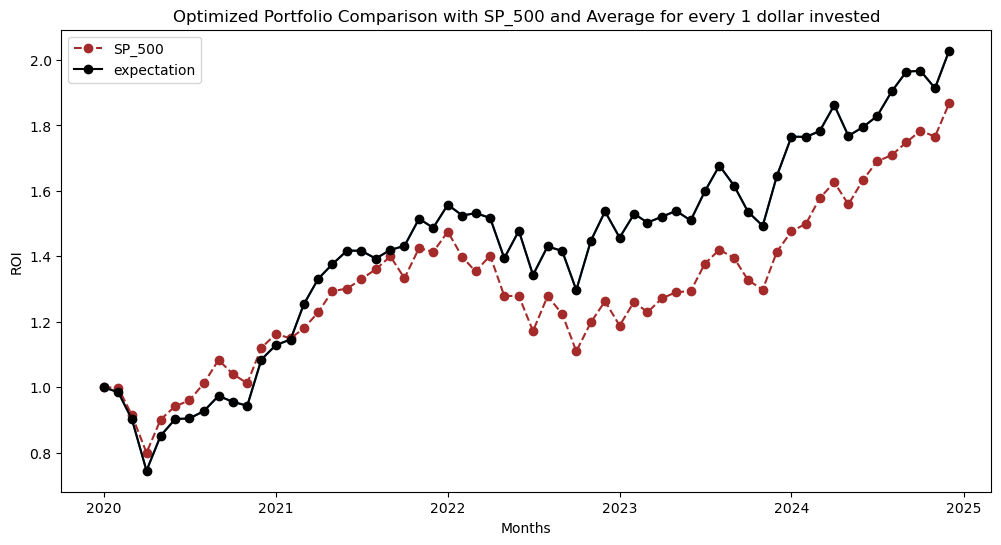


2020
1.0, 0.0, 0.2 

2020
1.0, 0.0, 0.2 

2020
1.0, 0.0, 0.2 

2020
1.0, 0.0, 0.2 

2020
1.0, 0.0, 0.2 

2020
1.0, 0.0, 0.2 

2020
1.0, 0.0, 0.2 

2020
1.0, 0.0, 0.2 

2020
1.0, 0.0, 0.2 

2020
1.0, 0.0, 0.2 

2020
1.0, 0.0, 0.2 

2020
1.0, 0.0, 0.2 

2021
1.0, 0.6, 0.6 

2021
1.0, 0.6, 0.6 

2021
1.0, 0.6, 0.6 

2021
1.0, 0.6, 0.6 

2021
1.0, 0.6, 0.6 

2021
1.0, 0.6, 0.6 

2021
1.0, 0.6, 0.6 

2021
1.0, 0.6, 0.6 

2021
1.0, 0.6, 0.6 

2021
1.0, 0.6, 0.6 

2021
1.0, 0.6, 0.6 

2021
1.0, 0.6, 0.6 

2022
1.0, 0.4, 0.6 

2022
1.0, 0.4, 0.6 

2022
1.0, 0.4, 0.6 

2022
1.0, 0.4, 0.6 

2022
1.0, 0.4, 0.6 

2022
1.0, 0.4, 0.6 

2022
1.0, 0.4, 0.6 

2022
1.0, 0.4, 0.6 

2022
1.0, 0.4, 0.6 

2022
1.0, 0.4, 0.6 

2022
1.0, 0.4, 0.6 

2022
1.0, 0.4, 0.6 

2023
0.9, 0.0, 0.2 

2023
0.9, 0.0, 0.2 

2023
0.9, 0.0, 0.2 

2023
0.9, 0.0, 0.2 

2023
0.9, 0.0, 0.2 

2023
0.9, 0.0, 0.2 

2023
0.9, 0.0, 0.2 

2023
0.9, 0.0, 0.2 

2023
0.9, 0.0, 0.2 

2023
0.9, 0.0, 0.2 

2023
0.9, 0.0, 0.2 

2023
0.9, 0.

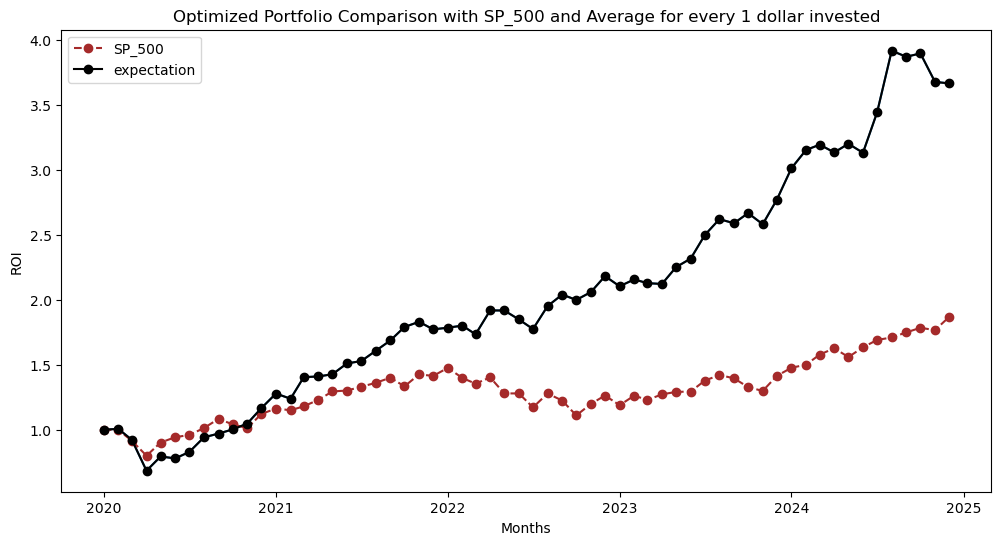

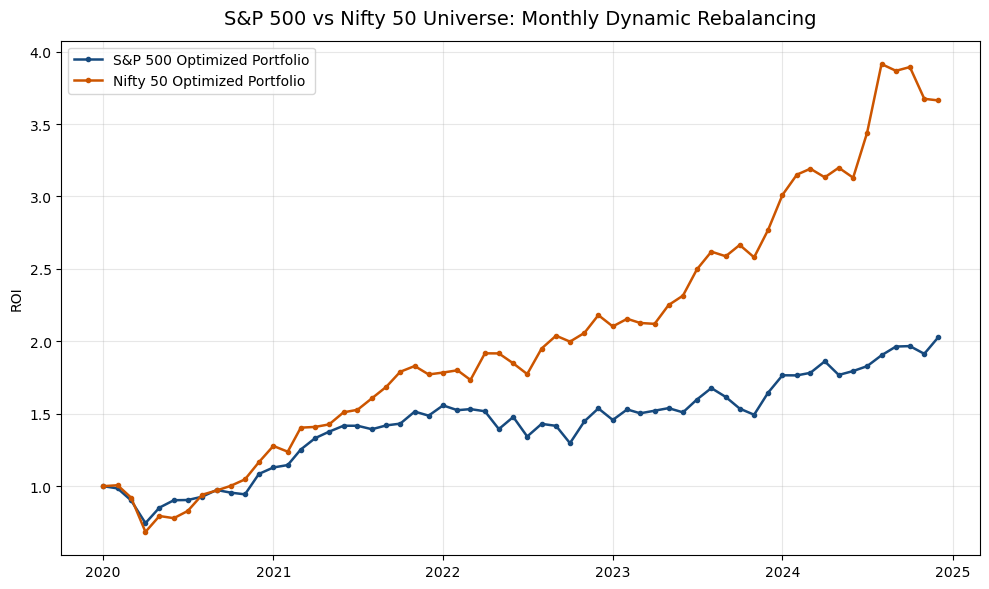

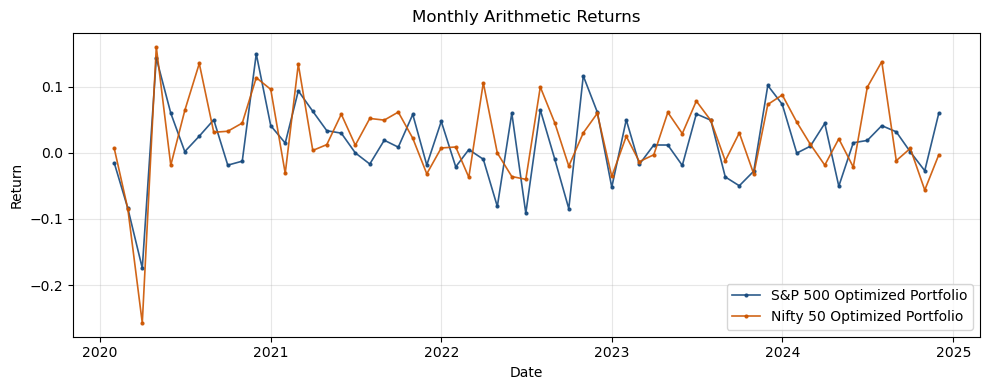

(            S&P 500 Optimized Portfolio  Nifty 50 Optimized Portfolio
 Date                                                                 
 2020-02-01                    -0.015278                      0.006627
 2020-03-01                    -0.083775                     -0.084582
 2020-04-01                    -0.174210                     -0.257131
 2020-05-01                     0.143453                      0.160110
 2020-06-01                     0.059976                     -0.018819
 2020-07-01                     0.001835                      0.064065
 2020-08-01                     0.025213                      0.135053
 2020-09-01                     0.049953                      0.031051
 2020-10-01                    -0.018631                      0.032628
 2020-11-01                    -0.012604                      0.045001
 2020-12-01                     0.149526                      0.113616
 2021-01-01                     0.041023                      0.095899
 2021-

In [210]:
new_data1=pd.read_csv('daat.csv')
new_data1.drop(columns='PERMNO',inplace=True)
new_data1.rename(columns={'date':'Date','TICKER':'Ticker'},inplace=True)
index=pd.read_csv('spy_data.csv')
indexgspc1=index.copy()
indexgspc1.rename(columns={'DATE':'Date','sprtrn':'SP_500'},inplace=True)
indexgspc1.drop(columns={'vwretd','spindx'},inplace=True)
indexgspc1.set_index('Date',inplace=True)
indexgspc1.index = pd.to_datetime(indexgspc1.index)
indexgspc1=indexgspc1.dropna()
spy_mom = pd.read_excel('Total SPX.xlsx')
spy_mom['Year'] = spy_mom['Source.Name'].str.extract(r'(\d{4})').astype(int)
spy_mom.set_index('Year', inplace = True)
spy_mom['Ticker'] = spy_mom['Ticker'].str.replace(r' [A-Z]{2,3} Equity$', '', regex=True)
spy_mom = spy_mom[['Ticker']]
spy_mom = spy_mom[~spy_mom['Ticker'].str.contains(r'\d', na=False)]
spy_mom = spy_mom.reset_index()
grouped = spy_mom.groupby('Year')['Ticker'].apply(list)
grouped = pd.DataFrame(grouped.tolist(), index=grouped.index)
grouped.columns = ["" for _ in grouped.columns]
spy_yoy_tickers1 = grouped
# y = yearly rebalancing
# m = monthly rebalancing
# dry = dynamic rebalancing yearly
# drm = dynamic rebalancing monthly

oos1_list,oos1_list_yearly,oos1_average=monte_carlo_simulation(1,0.9,0.3,0.0,'rebalance',3,5, 'drm')
sp_500_list = final_visual()
#   Indian Market Run 
new_data1=pd.read_csv('nifty_stocks_data (1).csv')
new_data1.drop(columns='PERMNO',inplace=True)
new_data1.rename(columns={'date':'Date','TICKER':'Ticker'},inplace=True)
index=pd.read_csv('spy_data.csv')
indexgspc1=index.copy()
indexgspc1.rename(columns={'DATE':'Date','sprtrn':'SP_500'},inplace=True)
indexgspc1.drop(columns={'vwretd','spindx'},inplace=True)
indexgspc1.set_index('Date',inplace=True)
indexgspc1.index = pd.to_datetime(indexgspc1.index)
indexgspc1=indexgspc1.dropna()
n_50 = pd.read_csv('Nifty_50.csv')
n_50 = n_50.replace("BAJAJ-AUTO", np.nan)

n_50.set_index('Year', inplace=True)
n50_view = n_50.copy()
n50_view.columns = [''] * n50_view.shape[1]
n50_view.index.name = 'Year'
n50_view.columns.name = None
n50_view = n50_view.astype(object).where(n50_view.notna(), None)
spy_yoy_tickers1 = n50_view.copy()
oos1_list,oos1_list_yearly,oos1_average=monte_carlo_simulation(1,0.9,0.3,0.0,'rebalance',3,5, 'drm')
n_50_list = final_visual()

combined_list = n_50_list
combined_list = combined_list.rename(columns = {'Optimized Portfolio':'Nifty 50 Optimized Portfolio'})
combined_list['SP_500'] = sp_500_list['Optimized Portfolio']
combined_list = combined_list.rename(columns = {'SP_500':'S&P 500 Optimized Portfolio'})
analyze_portfolios(combined_list, 12, .00206)

In [209]:

def analyze_portfolios(df_roi,
                       risk_free_monthly,
                       periods_per_year: int = 12):
    # 1) Monthly arithmetic returns
    monthly_ret = df_roi.pct_change().dropna()

    # 2) Summary statistics
    cumulative_ret = df_roi.iloc[-1] / df_roi.iloc[0] - 1
    ann_return = (df_roi.iloc[-1] / df_roi.iloc[0])**(periods_per_year / len(df_roi)) - 1
    vol = monthly_ret.std() * np.sqrt(periods_per_year)
    downside = monthly_ret.clip(upper=0)
    downside_vol = downside.std() * np.sqrt(periods_per_year)

    excess = monthly_ret.sub(risk_free_monthly)
    ann_excess_ret = excess.mean() * periods_per_year

    sharpe = ann_excess_ret / vol
    sortino = ann_excess_ret / downside_vol

    stats = pd.DataFrame({
        "Cumulative Return (%)": cumulative_ret.mul(100).round(2),
        "Annualized Return (%)": ann_return.mul(100).round(2),
        "Volatility (%)":        vol.mul(100).round(2),
        "Downside Vol (%)":      downside_vol.mul(100).round(2),
        "Sharpe":                sharpe.round(3),
        "Sortino":               sortino.round(3)
    }).T

    # --- Colors
    monthly_dyn_color = '#174a7e'   # blue
    yearly_dyn_color  = '#cc5500'   # orange
    nondyn_color      = 'black'     # non-dynamic / benchmark

    def color_for(col_name: str) -> str:
        # Dynamic first
        #if "Dynamic" in col_name:
        if "S&P" in col_name:
            return monthly_dyn_color
        if "Nifty" in col_name:
            return yearly_dyn_color
        # return monthly_dyn_color  # fallback for other dynamic labels
    # Non-dynamic (optimized, SP500, etc.)
        return nondyn_color

    # Helper: mark only January points for yearly series
    jan_marks = [i for i, d in enumerate(df_roi.index) if getattr(d, "month", None) == 1]

    # 3) Cumulative ROI plot
    fig, ax = plt.subplots(figsize=(10, 6))
    for col in df_roi.columns:
        col_color = color_for(col)
        if "Dynamic" in col and "Yearly" in col:
            ax.plot(df_roi.index, df_roi[col],
                    label=col, linewidth=1.8, color=col_color,
                    marker="o", markersize=5, markevery=jan_marks)
        else:
            ax.plot(df_roi.index, df_roi[col],
                    label=col, linewidth=1.8, color=col_color,
                    marker="o", markersize=3)
    ax.set_title("S&P 500 vs Nifty 50 Universe: Monthly Dynamic Rebalancing", fontsize=14, pad=12)
    ax.set_ylabel("ROI")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()

    # 4) Monthly returns plot (manual to keep identical colors)
    fig2, ax2 = plt.subplots(figsize=(10, 4))
    for col in monthly_ret.columns:
        ax2.plot(monthly_ret.index, monthly_ret[col],
                 label=col, linewidth=1.2, marker="o", markersize=2,
                 color=color_for(col), alpha=0.9)
    ax2.set_title("Monthly Arithmetic Returns", fontsize=12, pad=8)
    ax2.set_xlabel("Date"); ax2.set_ylabel("Return")
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    fig2.tight_layout()
    plt.show()

    return monthly_ret, stats


Column 'FTI' could not be converted to float.
1.0, 0.0, 0.2 
1.0, 0.6, 0.6 
1.0, 0.4, 0.6 
0.9, 0.0, 0.2 
0.9, 0.0, 0.2 
Column 'FTI' could not be converted to float.
1.0, 0.0, 0.2 
1.0, 0.6, 0.6 
1.0, 0.4, 0.6 
0.9, 0.0, 0.2 
0.9, 0.0, 0.2 
Column 'FTI' could not be converted to float.
1.0, 0.0, 0.2 
1.0, 0.6, 0.6 
1.0, 0.4, 0.6 
0.9, 0.0, 0.2 
0.9, 0.0, 0.2 


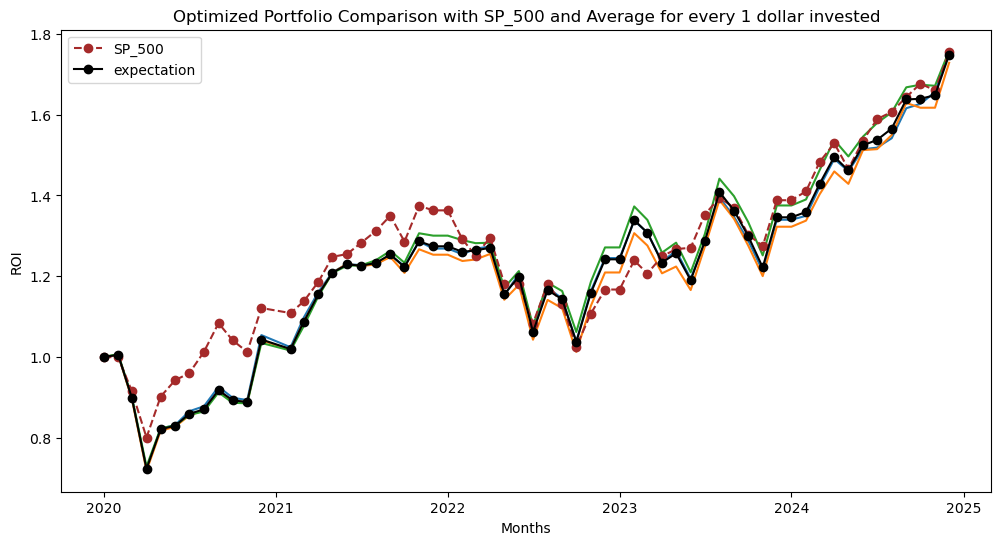

1.0, 0.0, 0.2 
1.0, 0.6, 0.6 
1.0, 0.4, 0.6 
0.9, 0.0, 0.2 
0.9, 0.0, 0.2 
1.0, 0.0, 0.2 
1.0, 0.6, 0.6 
1.0, 0.4, 0.6 
0.9, 0.0, 0.2 
0.9, 0.0, 0.2 
1.0, 0.0, 0.2 
1.0, 0.6, 0.6 
1.0, 0.4, 0.6 
0.9, 0.0, 0.2 
0.9, 0.0, 0.2 


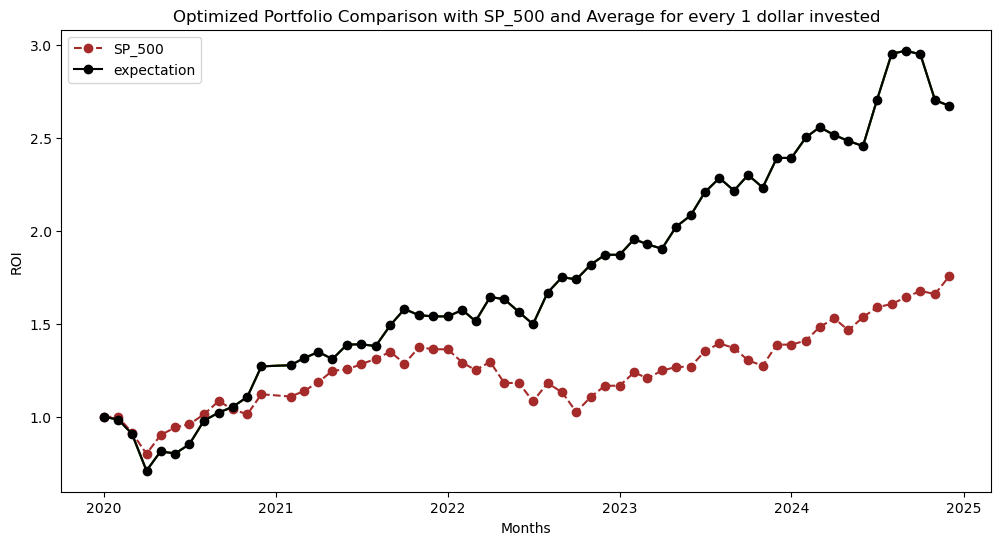

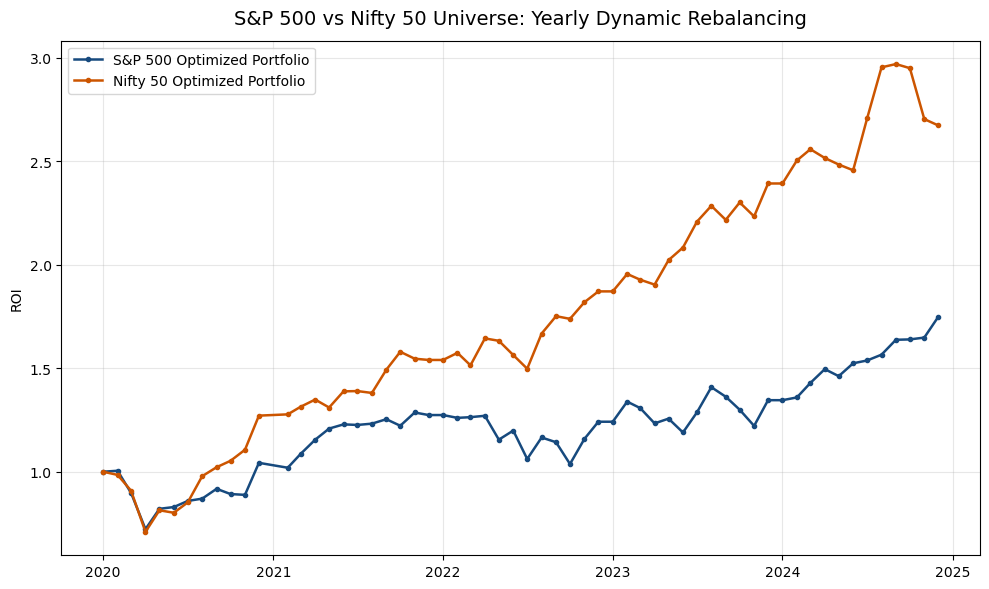

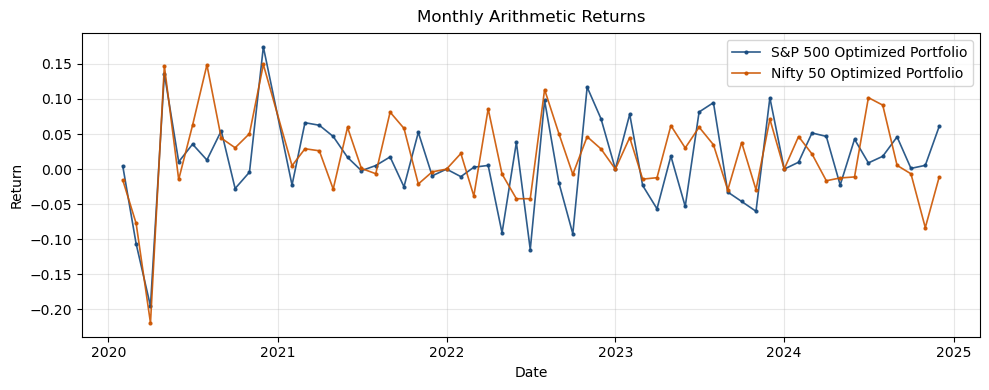

(            S&P 500 Optimized Portfolio  Nifty 50 Optimized Portfolio
 Date                                                                 
 2020-02-01                     0.004704                     -0.015379
 2020-03-01                    -0.106540                     -0.077426
 2020-04-01                    -0.195348                     -0.219299
 2020-05-01                     0.136213                      0.147267
 2020-06-01                     0.010409                     -0.014782
 2020-07-01                     0.035573                      0.062642
 2020-08-01                     0.013014                      0.148689
 2020-09-01                     0.054590                      0.044242
 2020-10-01                    -0.027663                      0.030447
 2020-11-01                    -0.004312                      0.050541
 2020-12-01                     0.174268                      0.149202
 2021-02-01                    -0.022708                      0.004856
 2021-

In [212]:
new_data1=pd.read_csv('daat.csv')
new_data1.drop(columns='PERMNO',inplace=True)
new_data1.rename(columns={'date':'Date','TICKER':'Ticker'},inplace=True)
index=pd.read_csv('spy_data.csv')
indexgspc1=index.copy()
indexgspc1.rename(columns={'DATE':'Date','sprtrn':'SP_500'},inplace=True)
indexgspc1.drop(columns={'vwretd','spindx'},inplace=True)
indexgspc1.set_index('Date',inplace=True)
indexgspc1.index = pd.to_datetime(indexgspc1.index)
indexgspc1=indexgspc1.dropna()
spy_mom = pd.read_excel('Total SPX.xlsx')
spy_mom['Year'] = spy_mom['Source.Name'].str.extract(r'(\d{4})').astype(int)
spy_mom.set_index('Year', inplace = True)
spy_mom['Ticker'] = spy_mom['Ticker'].str.replace(r' [A-Z]{2,3} Equity$', '', regex=True)
spy_mom = spy_mom[['Ticker']]
spy_mom = spy_mom[~spy_mom['Ticker'].str.contains(r'\d', na=False)]
spy_mom = spy_mom.reset_index()
grouped = spy_mom.groupby('Year')['Ticker'].apply(list)
grouped = pd.DataFrame(grouped.tolist(), index=grouped.index)
grouped.columns = ["" for _ in grouped.columns]
spy_yoy_tickers1 = grouped
# y = yearly rebalancing
# m = monthly rebalancing
# dry = dynamic rebalancing yearly
# drm = dynamic rebalancing monthly

oos1_list,oos1_list_yearly,oos1_average=monte_carlo_simulation(3,0.9,0.3,0.0,'rebalance',3,5, 'dry')
sp_500_list = final_visual()
#   Indian Market Run 
new_data1=pd.read_csv('nifty_stocks_data (1).csv')
new_data1.drop(columns='PERMNO',inplace=True)
new_data1.rename(columns={'date':'Date','TICKER':'Ticker'},inplace=True)
index=pd.read_csv('spy_data.csv')
indexgspc1=index.copy()
indexgspc1.rename(columns={'DATE':'Date','sprtrn':'SP_500'},inplace=True)
indexgspc1.drop(columns={'vwretd','spindx'},inplace=True)
indexgspc1.set_index('Date',inplace=True)
indexgspc1.index = pd.to_datetime(indexgspc1.index)
indexgspc1=indexgspc1.dropna()
n_50 = pd.read_csv('Nifty_50.csv')
n_50 = n_50.replace("BAJAJ-AUTO", np.nan)

n_50.set_index('Year', inplace=True)
n50_view = n_50.copy()
n50_view.columns = [''] * n50_view.shape[1]
n50_view.index.name = 'Year'
n50_view.columns.name = None
n50_view = n50_view.astype(object).where(n50_view.notna(), None)
spy_yoy_tickers1 = n50_view.copy()
oos1_list,oos1_list_yearly,oos1_average=monte_carlo_simulation(3,0.9,0.3,0.0,'rebalance',3,5, 'dry')
n_50_list = final_visual()

combined_list = n_50_list
combined_list = combined_list.rename(columns = {'Optimized Portfolio':'Nifty 50 Optimized Portfolio'})
combined_list['SP_500'] = sp_500_list['Optimized Portfolio']
combined_list = combined_list.rename(columns = {'SP_500':'S&P 500 Optimized Portfolio'})
analyze_portfolios(combined_list, 12, .00206)

In [211]:

def analyze_portfolios(df_roi,
                       risk_free_monthly,
                       periods_per_year: int = 12):
    # 1) Monthly arithmetic returns
    monthly_ret = df_roi.pct_change().dropna()

    # 2) Summary statistics
    cumulative_ret = df_roi.iloc[-1] / df_roi.iloc[0] - 1
    ann_return = (df_roi.iloc[-1] / df_roi.iloc[0])**(periods_per_year / len(df_roi)) - 1
    vol = monthly_ret.std() * np.sqrt(periods_per_year)
    downside = monthly_ret.clip(upper=0)
    downside_vol = downside.std() * np.sqrt(periods_per_year)

    excess = monthly_ret.sub(risk_free_monthly)
    ann_excess_ret = excess.mean() * periods_per_year

    sharpe = ann_excess_ret / vol
    sortino = ann_excess_ret / downside_vol

    stats = pd.DataFrame({
        "Cumulative Return (%)": cumulative_ret.mul(100).round(2),
        "Annualized Return (%)": ann_return.mul(100).round(2),
        "Volatility (%)":        vol.mul(100).round(2),
        "Downside Vol (%)":      downside_vol.mul(100).round(2),
        "Sharpe":                sharpe.round(3),
        "Sortino":               sortino.round(3)
    }).T

    # --- Colors
    monthly_dyn_color = '#174a7e'   # blue
    yearly_dyn_color  = '#cc5500'   # orange
    nondyn_color      = 'black'     # non-dynamic / benchmark

    def color_for(col_name: str) -> str:
        # Dynamic first
        #if "Dynamic" in col_name:
        if "S&P" in col_name:
            return monthly_dyn_color
        if "Nifty" in col_name:
            return yearly_dyn_color
        # return monthly_dyn_color  # fallback for other dynamic labels
    # Non-dynamic (optimized, SP500, etc.)
        return nondyn_color

    # Helper: mark only January points for yearly series
    jan_marks = [i for i, d in enumerate(df_roi.index) if getattr(d, "month", None) == 1]

    # 3) Cumulative ROI plot
    fig, ax = plt.subplots(figsize=(10, 6))
    for col in df_roi.columns:
        col_color = color_for(col)
        if "Dynamic" in col and "Yearly" in col:
            ax.plot(df_roi.index, df_roi[col],
                    label=col, linewidth=1.8, color=col_color,
                    marker="o", markersize=5, markevery=jan_marks)
        else:
            ax.plot(df_roi.index, df_roi[col],
                    label=col, linewidth=1.8, color=col_color,
                    marker="o", markersize=3)
    ax.set_title("S&P 500 vs Nifty 50 Universe: Yearly Dynamic Rebalancing", fontsize=14, pad=12)
    ax.set_ylabel("ROI")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()

    # 4) Monthly returns plot (manual to keep identical colors)
    fig2, ax2 = plt.subplots(figsize=(10, 4))
    for col in monthly_ret.columns:
        ax2.plot(monthly_ret.index, monthly_ret[col],
                 label=col, linewidth=1.2, marker="o", markersize=2,
                 color=color_for(col), alpha=0.9)
    ax2.set_title("Monthly Arithmetic Returns", fontsize=12, pad=8)
    ax2.set_xlabel("Date"); ax2.set_ylabel("Return")
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    fig2.tight_layout()
    plt.show()

    return monthly_ret, stats


In [138]:
new_data1=pd.read_csv('daat.csv')
new_data1.drop(columns='PERMNO',inplace=True)
new_data1.rename(columns={'date':'Date','TICKER':'Ticker'},inplace=True)
index=pd.read_csv('spy_data.csv')
indexgspc1=index.copy()
indexgspc1.rename(columns={'DATE':'Date','sprtrn':'SP_500'},inplace=True)
indexgspc1.drop(columns={'vwretd','spindx'},inplace=True)
indexgspc1.set_index('Date',inplace=True)
indexgspc1.index = pd.to_datetime(indexgspc1.index)
indexgspc1=indexgspc1.dropna()
spy_mom = pd.read_excel('Total SPX.xlsx')
spy_mom['Year'] = spy_mom['Source.Name'].str.extract(r'(\d{4})').astype(int)
spy_mom.set_index('Year', inplace = True)
spy_mom['Ticker'] = spy_mom['Ticker'].str.replace(r' [A-Z]{2,3} Equity$', '', regex=True)
spy_mom = spy_mom[['Ticker']]
spy_mom = spy_mom[~spy_mom['Ticker'].str.contains(r'\d', na=False)]
spy_mom = spy_mom.reset_index()
grouped = spy_mom.groupby('Year')['Ticker'].apply(list)
grouped = pd.DataFrame(grouped.tolist(), index=grouped.index)
grouped.columns = ["" for _ in grouped.columns]
spy_yoy_tickers1 = grouped

# Analysis here and run simulations here

In [160]:
# y = yearly rebalancing
# m = monthly rebalancing
# dry = dynamic rebalancing yearly
# drm = dynamic rebalancing monthly

oos1_list,oos1_list_yearly,oos1_average=monte_carlo_simulation(3,0.9,0.3,0.0,'rebalance',3,5, 'dry')

Column 'FTI' could not be converted to float.
1.0, 0.0, 0.2 
1.0, 0.6, 0.6 
1.0, 0.4, 0.6 
0.9, 0.0, 0.2 
0.9, 0.0, 0.2 
Column 'FTI' could not be converted to float.
1.0, 0.0, 0.2 
1.0, 0.6, 0.6 
1.0, 0.4, 0.6 
0.9, 0.0, 0.2 
0.9, 0.0, 0.2 
Column 'FTI' could not be converted to float.
1.0, 0.0, 0.2 
1.0, 0.6, 0.6 
1.0, 0.4, 0.6 
0.9, 0.0, 0.2 
0.9, 0.0, 0.2 


In [222]:
mr = mr.cumprod()

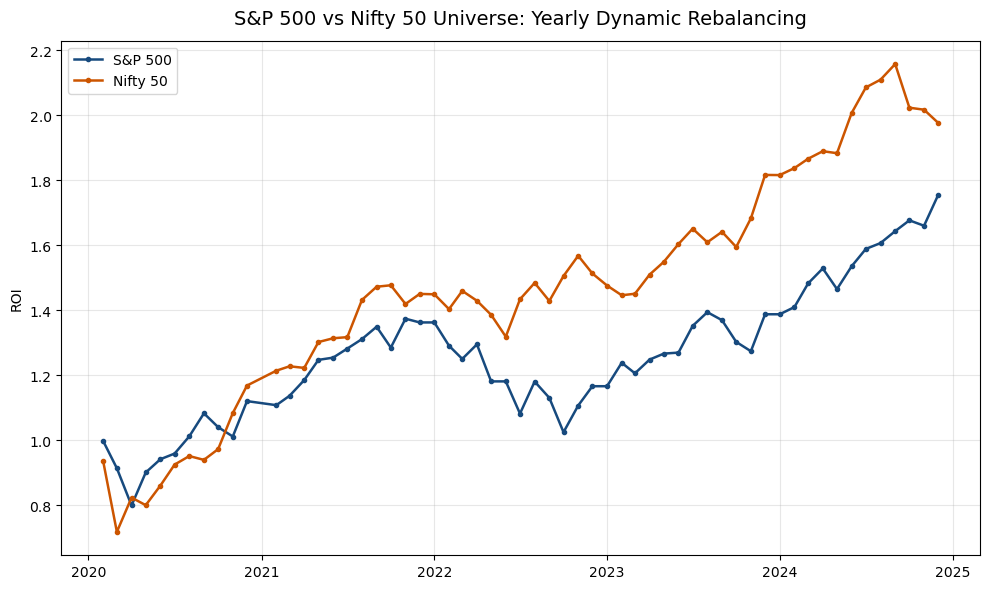

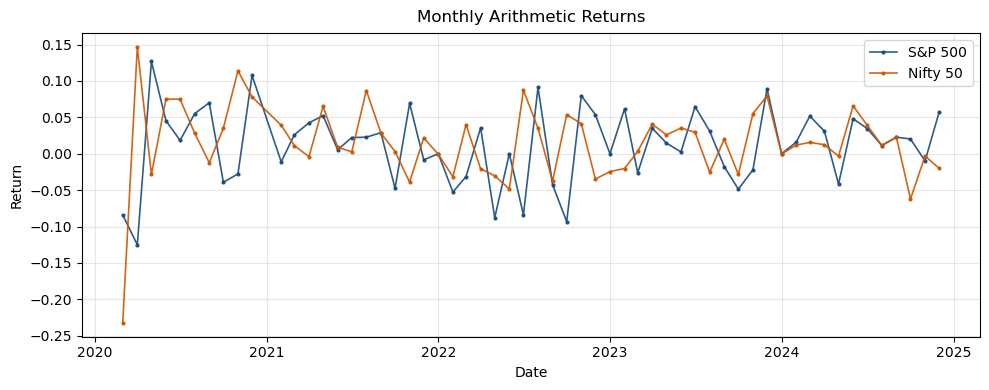

Ticker,S&P 500,Nifty 50
Cumulative Return (%),75.840,111.080
Annualized Return (%),12.390,16.720
Volatility (%),18.150,18.710
Downside Vol (%),10.140,11.510
Sharpe,0.609,0.808
Sortino,1.091,1.314


In [223]:
monthly_returns, summary_table = analyze_portfolios(mr, risk_free_monthly = 0.00209)
display(summary_table) # monthly rf rate

In [163]:
#   Indian Market Run 
new_data1=pd.read_csv('nifty_stocks_data (1).csv')
new_data1.drop(columns='PERMNO',inplace=True)
new_data1.rename(columns={'date':'Date','TICKER':'Ticker'},inplace=True)
index=pd.read_csv('spy_data.csv')
indexgspc1=index.copy()
indexgspc1.rename(columns={'DATE':'Date','sprtrn':'SP_500'},inplace=True)
indexgspc1.drop(columns={'vwretd','spindx'},inplace=True)
indexgspc1.set_index('Date',inplace=True)
indexgspc1.index = pd.to_datetime(indexgspc1.index)
indexgspc1=indexgspc1.dropna()
n_50 = pd.read_csv('Nifty_50.csv')
n_50 = n_50.replace("BAJAJ-AUTO", np.nan)

n_50.set_index('Year', inplace=True)
n50_view = n_50.copy()
n50_view.columns = [''] * n50_view.shape[1]
n50_view.index.name = 'Year'
n50_view.columns.name = None
n50_view = n50_view.astype(object).where(n50_view.notna(), None)
spy_yoy_tickers1 = n50_view.copy()

In [164]:
# y = yearly rebalancing
# m = monthly rebalancing
# dry = dynamic rebalancing yearly
# drm = dynamic rebalancing monthly

oos1_list,oos1_list_yearly,oos1_average=monte_carlo_simulation(3,0.9,0.3,0.0,'rebalance',3,5, 'dry')

1.0, 0.0, 0.2 
1.0, 0.6, 0.6 
1.0, 0.4, 0.6 
0.9, 0.0, 0.2 
0.9, 0.0, 0.2 
1.0, 0.0, 0.2 
1.0, 0.6, 0.6 
1.0, 0.4, 0.6 
0.9, 0.0, 0.2 
0.9, 0.0, 0.2 
1.0, 0.0, 0.2 
1.0, 0.6, 0.6 
1.0, 0.4, 0.6 
0.9, 0.0, 0.2 
0.9, 0.0, 0.2 


In [213]:
N50

,ROI
Date,
2020-01-01,1.000000
2020-02-01,0.936437
2020-03-01,0.718749
2020-04-01,0.824262
2020-05-01,0.800888
2020-06-01,0.861228
2020-07-01,0.925711
2020-08-01,0.951965
2020-09-01,0.940266


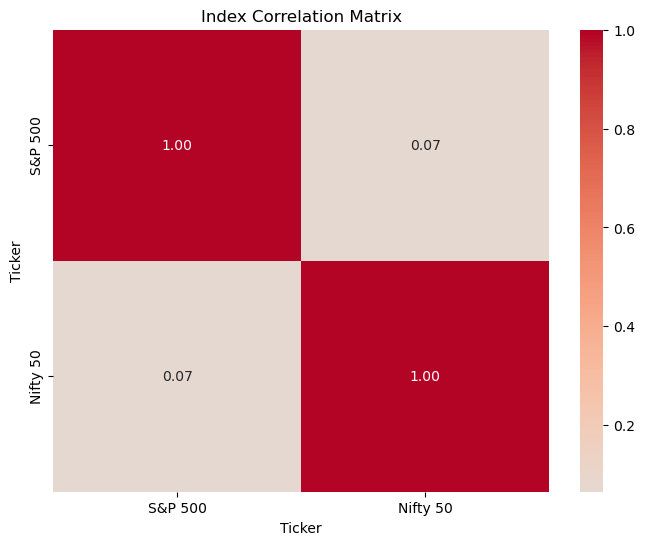

In [208]:
corr = mr.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Index Correlation Matrix")
plt.show()

In [136]:
for t in n_50.loc[2020]:
    if t in price_monthly_data.columns:
        print(t)

ADANIPORTS
ASIANPAINT
AXISBANK
BAJAJ-AUTO
BAJFINANCE
BAJAJFINSV
BHARTIARTL
CIPLA
COALINDIA
DRREDDY
EICHERMOT
GRASIM
HCLTECH
HEROMOTOCO
HINDALCO
HINDUNILVR
ICICIBANK
INDUSINDBK
INFY
ITC
JSWSTEEL
KOTAKBANK
LT
M&M
MARUTI
NESTLEIND
NTPC
ONGC
POWERGRID
RELIANCE
SBIN
SUNPHARMA
TCS
TATAMOTORS
TATASTEEL
TECHM
TITAN
ULTRACEMCO
WIPRO
BRITANNIA
BPCL
UPL
HDFCBANK
SHREECEM
IOC
GAIL
ZEEL
VEDL


In [109]:
avg100m = avg100m.rename(columns={'Optimized Portfolio': 'Optimized Portfolio (Monthly Dynamic Rebalancing)'})

In [110]:
avg100m = avg100m.drop(columns= {'SP_500'})

In [111]:
montlhy_rebal_list = montlhy_rebal_list.rename(columns={'Optimized Portfolio': 'Optimized Portfolio (Monthly Rebalancing)'})

In [113]:
montlhy_rebal_list['Optimized Portfolio (Monthly Dynamic Rebalancing)'] = avg100m[['Optimized Portfolio (Monthly Dynamic Rebalancing)']]

In [115]:
montlhy_rebal_list = montlhy_rebal_list.drop(columns = {'SP_500'})

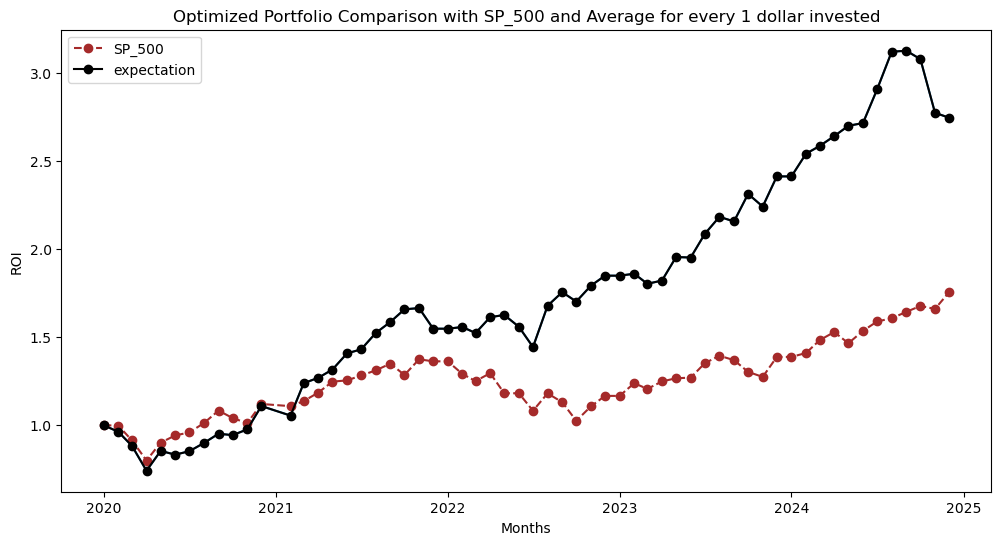

In [181]:
avg100y = final_visual()

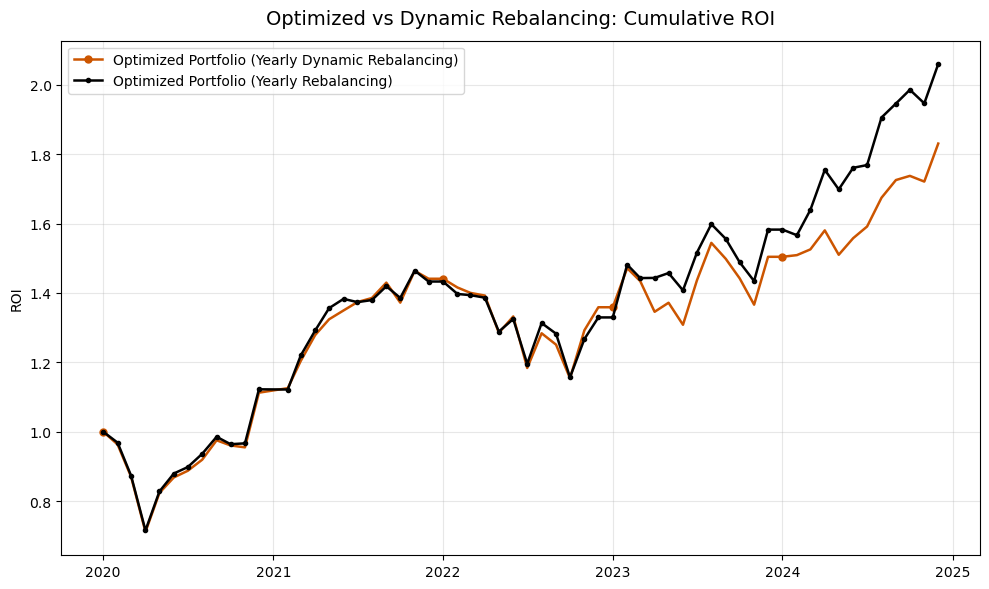

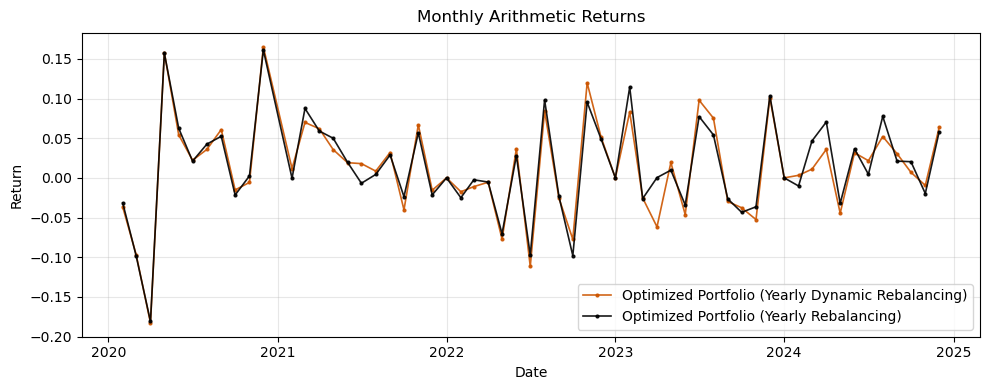

,Optimized Portfolio (Yearly Dynamic Rebalancing),Optimized Portfolio (Yearly Rebalancing)
Cumulative Return (%),83.050,105.970
Annualized Return (%),13.080,15.830
Volatility (%),21.640,21.360
Downside Vol (%),11.910,11.460
Sharpe,0.572,0.692
Sortino,1.039,1.289


In [ ]:
monthly_returns, summary_table = analyze_portfolios(yearly_rebal_list, risk_free_monthly = 0.00209)
display(summary_table) # monthly rf rate

In [66]:
montlhy_rebal_list = montlhy_rebal_list.rename(columns={'Optimized Portfolio': 'Optimized Portfolio (Monthly Rebalancing)'})

In [67]:
montlhy_rebal_list['Optimized Portfolio (Yearly Rebalancing)'] = yearly_rebal_list[['Optimized Portfolio (Yearly Rebalancing)']]

NameError: name 'yearly_rebal_list' is not defined

# Reinforcement Learning
### Skip this if not using 

In [ ]:
def get_consistently_worst_portfolio(dfs, portfolio_col='portfolio'):
    """
    Returns the DataFrame whose portfolio is consistently the worst performer.

    Parameters:
        dfs (list of pd.DataFrame): Each must have a 'portfolio' and 'sp500' column.
        portfolio_col (str): The portfolio column name.

    Returns:
        pd.DataFrame: The worst performing portfolio's full DataFrame.
    """

    # Extract and align all portfolio series
    portfolio_series_list = [df[portfolio_col] for df in dfs]

    # Align all series to the same index (intersection of all indices)
    common_index = set(portfolio_series_list[0].index)
    for series in portfolio_series_list[1:]:
        common_index &= set(series.index)
    common_index = sorted(common_index)

    # Reindex all series to common index
    aligned_series = [s.loc[common_index] for s in portfolio_series_list]

    # Combine into one DataFrame
    combined_portfolios = pd.concat(aligned_series, axis=1)

    # Count how often each portfolio is the minimum
    min_counts = (combined_portfolios == combined_portfolios.min(axis=1, skipna=True)).sum()

    # Get index of portfolio that's worst most often
    worst_index = min_counts.idxmax()

    # Return the full original DataFrame for that portfolio
    return dfs[worst_index]

In [ ]:
 

class AdaptiveBandit:
    def __init__(self, target_years=5, objective='max_return'):
        self.target_years = target_years
        self.objective = objective.lower()  # Objective: 'max_return', 'downside_protection', 'sharpe', 'sortino'
        self.best_combination = np.array([1.0, 0.0, 0.0])
        self.best_return = -np.inf

    def evaluate_combination(self, beta_combination):
        # Replace this call with your real monte_carlo_simulation logic
        
        oos1_list,oos1_list_yearly,oos1_average=monte_carlo_simulation(1,1,0,0,'rebalance',3,5, 'm')        
        if self.objective == 'max_return':
            simulated_df=final_visual()
        else:
            simulated_df=get_consistently_worst_portfolio(oos1_list,'Optimized Portfolio')
        return simulated_df

    def reward_function(self, simulated_df):
        if self.objective == 'max_return':
            optimized_cumulative_return = simulated_df['Optimized Portfolio'].iloc[-1]
            sp500_cumulative_return = simulated_df['SP_500'].iloc[-1]
            reward = optimized_cumulative_return / sp500_cumulative_return

        elif self.objective == 'downside_protection':
            returns_spy = simulated_df['SP_500'].pct_change().dropna()
            downside_returns_spy = returns_spy[returns_spy < 0]  
            downside_vol_spy = np.sqrt((downside_returns_spy ** 2).mean()) * np.sqrt(12)

            returns_opt = simulated_df['Optimized Portfolio'].pct_change().dropna()
            downside_returns_opt = returns_opt[returns_opt < 0]  
            downside_vol_opt = np.sqrt((downside_returns_opt ** 2).mean()) * np.sqrt(12)
            
            reward = downside_vol_spy/downside_vol_opt

        elif self.objective == 'sharpe':
            returns = simulated_df['Optimized Portfolio'].pct_change().dropna()
            mean_return = returns.mean()
            std_return = returns.std()
            reward = mean_return / std_return if std_return != 0 else -np.inf

        elif self.objective == 'sortino':
            returns = simulated_df['Optimized Portfolio'].pct_change().dropna()
            mean_return = returns.mean()
            downside_std = returns[returns < 0].std()
            reward = mean_return / downside_std if downside_std != 0 else -np.inf
        else:
            raise ValueError(f"Unknown objective: {self.objective}")

        return reward

    def select_next_combination(self):
        candidates = []
        for i in range(3):
            new_combination = self.best_combination.copy()
            new_combination[i] += 0.1
            new_combination = np.clip(new_combination, 0.7, 2)
            simulated_df = self.evaluate_combination(new_combination)
            reward = self.reward_function(simulated_df)
            candidates.append((new_combination, reward))

        candidates.sort(key=lambda x: x[1], reverse=True)

        if candidates[0][1] > self.best_return:
            self.best_combination = candidates[0][0]
            self.best_return = candidates[0][1]
            return self.best_combination

        return self.best_combination

    def run_bandit(self, iterations=50):
        for i in range(iterations):
            new_combination = self.select_next_combination()
            print(f"Iteration {i+1}, Best Combination: {new_combination}, Best Score ({self.objective}): {self.best_return:.4f}")

        print("\nFinal Best Combination Found:")
        print(f"Best Combination: {self.best_combination}, Best Score ({self.objective}): {self.best_return:.4f}")


In [ ]:
import numpy as np
import pandas as pd
import os

class AdaptiveBandit:
    def __init__(self, target_years=5, objective='max_return'):
        self.target_years = target_years
        self.objective = objective.lower()
        self.best_combination = np.array([1.0, 0.0, 0.0])
        self.best_return = -np.inf
        self.storage_file = f"mrebal_explored_{self.objective}.csv"
        self.explored = self.load_explored_combinations()
    def load_explored_combinations(self):
        if os.path.exists(self.storage_file):
            df = pd.read_csv(self.storage_file)
            df[['c1', 'c2', 'c3', 'reward']] = df[['c1', 'c2', 'c3', 'reward']].astype(float)
            return df
        return pd.DataFrame(columns=['c1', 'c2', 'c3', 'reward'])


    def save_combination(self, combination, reward):
        new_entry = pd.DataFrame([{
            'c1': combination[0],
            'c2': combination[1],
            'c3': combination[2],
            'reward': reward
        }])
        self.explored = pd.concat([self.explored, new_entry], ignore_index=True)
        self.explored.to_csv(self.storage_file, index=False)
    def save_combination(self, combination, reward):
        combination = np.array(combination, dtype=float)
        reward = float(reward)
        new_entry = pd.DataFrame([{
            'c1': combination[0],
            'c2': combination[1],
            'c3': combination[2],
            'reward': reward
        }])
        self.explored = pd.concat([self.explored, new_entry], ignore_index=True)
        self.explored.to_csv(self.storage_file, index=False)
    def save_combination(self, combination, reward):
        combination = self.round_combination(combination)
        reward = float(reward)
    
        if self.check_existing_combination(combination) is not None:
            return  # Skip if already saved

        new_entry = pd.DataFrame([{
            'c1': combination[0],
            'c2': combination[1],
            'c3': combination[2],
            'reward': reward
        }])
        self.explored = pd.concat([self.explored, new_entry], ignore_index=True)
        self.explored.to_csv(self.storage_file, index=False)



    def check_existing_combination(self, combination):
        combination = self.round_combination(combination)
        match = self.explored[
            (self.explored['c1'] == combination[0]) &
            (self.explored['c2'] == combination[1]) &
            (self.explored['c3'] == combination[2])
        ]
        if not match.empty:
            return match.iloc[0]['reward']
        return None

    def round_combination(self, combination):
        return np.round(np.array(combination, dtype=float), 1)



    def evaluate_combination(self, beta_combination):
        betaa = beta_combination[0]
        betab = beta_combination[1]
        betac = beta_combination[2]
        oos1_list,oos1_list_yearly,oos1_average=monte_carlo_simulation(1,betaa, betab, betac,'rebalance', 3,5, 'm')
        if self.objective == 'max_return':
            simulated_df = sp_final_visual()
        else:
            simulated_df = get_consistently_worst_portfolio(oos1_list, 'Optimized Portfolio')
        return simulated_df

    def reward_function(self, simulated_df):
        if self.objective in ['max_return', 'downside_protection']:
            returns_spy = simulated_df['SP_500'].pct_change().dropna()
            downside_returns_spy = returns_spy[returns_spy < 0]  
            downside_vol_spy = np.sqrt((downside_returns_spy ** 2).mean()) * np.sqrt(12)

            returns_opt = simulated_df['Optimized Portfolio'].pct_change().dropna()
            downside_returns_opt = returns_opt[returns_opt < 0]  
            downside_vol_opt = np.sqrt((downside_returns_opt ** 2).mean()) * np.sqrt(12)
            
            reward = downside_vol_spy/downside_vol_opt
            return reward

        returns = simulated_df['Optimized Portfolio'].pct_change().dropna()
        if self.objective == 'sharpe':
            return returns.mean() / returns.std() if returns.std() != 0 else -np.inf
        elif self.objective == 'sortino':
            returns_spy = simulated_df['SP_500'].pct_change().dropna()
            downside_returns_spy = returns_spy[returns_spy < 0]  
            downside_vol_spy = np.sqrt((downside_returns_spy ** 2).mean()) * np.sqrt(12)

            returns_opt = simulated_df['Optimized Portfolio'].pct_change().dropna()
            downside_returns_opt = returns_opt[returns_opt < 0]  
            downside_vol_opt = np.sqrt((downside_returns_opt ** 2).mean()) * np.sqrt(12)
            
            reward = downside_vol_spy/downside_vol_opt
            return reward
        else:
            raise ValueError(f"Unknown objective: {self.objective}")

    # def explore_direction(self, base_combination):
    #     candidates = []
    #     directions = [-0.1, 0.1]
    #     lower_bounds = np.array([0.9, 0.0, 0.0])
    #     upper_bounds = np.array([2.3, 2.2, 2.2])
    
    #     for i in range(3):
    #         for delta in directions:
    #             new_combination = base_combination.copy()
    #             new_combination[i] += delta
    #             new_combination = np.clip(new_combination, lower_bounds, upper_bounds)

    #             existing = self.check_existing_combination(new_combination)
    #             if existing is not None:
    #                 reward = existing
    #             else:
    #                 simulated_df = self.evaluate_combination(new_combination)
    #                 reward = self.reward_function(simulated_df)
    #                 self.save_combination(new_combination, reward)

    #             candidates.append((new_combination, reward))

    #     return candidates
    def explore_direction(self, base_combination):
        candidates = []
        directions = [-0.1, 0.2]
        lower_bounds = np.array([0.9, 0.0, 0.0])
        upper_bounds = np.array([2.3, 2.2, 2.2])
        found_new = False

        for i in range(3):
            for delta in directions:
                new_combination = base_combination.copy()
                new_combination[i] += delta
                new_combination = np.clip(new_combination, lower_bounds, upper_bounds)

                if self.check_existing_combination(new_combination) is not None:
                    continue  # Already explored, skip it

                new_combination = np.round(new_combination, 1)
                simulated_df = self.evaluate_combination(new_combination)
                reward = self.reward_function(simulated_df)
                self.save_combination(new_combination, reward)
                candidates.append((new_combination, reward))
                found_new = True
        

        return candidates, found_new



    # def select_next_combination(self):
    #     candidates = self.explore_direction(self.best_combination)

    # # Filter only those with unseen combinations (i.e., actually evaluated)
    #     new_explorations = [c for c in candidates if self.check_existing_combination(c[0]) is None]

    # # If all are previously explored, still pick the best for possible updates
    #     candidates.sort(key=lambda x: x[1], reverse=True)
    #     best_candidate, best_reward = candidates[0]

    #     was_new = best_candidate in [c[0] for c in new_explorations]

    #     if best_reward > self.best_return:
    #         self.best_combination = best_candidate
    #         self.best_return = best_reward

    #     return self.best_combination, was_new
    def select_next_combination(self):
        candidates, found_new = self.explore_direction(self.best_combination)

        if not candidates:
            return self.best_combination, False  # No new exploration found

        candidates.sort(key=lambda x: x[1], reverse=True)
        best_candidate, best_reward = candidates[0]

        if best_reward > self.best_return:
            self.best_combination = best_candidate
            self.best_return = best_reward

        return self.best_combination, found_new
    def run_bandit(self, iterations=3, initializer='yes'):
        print(f"Running bandit optimization for objective: '{self.objective}'")

    # Base initialization
        if initializer == 'yes':
            base = np.array([1.0, 0.7, 0.7])
        else:
            if not self.explored.empty:
                best_row = self.explored.loc[self.explored['reward'].idxmax()]
                base = np.array([best_row['c1'], best_row['c2'], best_row['c3']])
            else:
                print("No previous data found. Using default base combination.")
                base = np.array([1.0, 0.0, 0.0])

    # Evaluate base combo
        reward = self.check_existing_combination(base)
        if reward is None:
            simulated_df = self.evaluate_combination(base)
            reward = self.reward_function(simulated_df)
            self.save_combination(base, reward)

        self.best_combination = base
        self.best_return = reward

        print(f"Base Combination: {self.best_combination}, Base Score: {self.best_return:.4f}")

        valid_iterations = 0
        attempt_cap = iterations * 10  # Avoid infinite loops

        while valid_iterations < iterations and attempt_cap > 0:
            new_combination, found_new = self.select_next_combination()
            attempt_cap -= 1

            if found_new:
                valid_iterations += 1
                print(f"[{valid_iterations}] New Combo: {new_combination} → Score: {self.best_return:.4f}")
            else:
                print("No new combination found. Expanding search...")

            # Optional: add random direction or noise when stuck
                random_combo = self.best_combination + np.random.uniform(-0.2, 0.2, size=3)
                random_combo = np.clip(random_combo, [0.9, 0.0, 0.0], [2.3, 2.2, 2.2])

                if self.check_existing_combination(random_combo) is None:
                    simulated_df = self.evaluate_combination(random_combo)
                    reward = self.reward_function(simulated_df)
                    self.save_combination(random_combo, reward)

                    if reward > self.best_return:
                        self.best_combination = random_combo
                        self.best_return = reward
                        valid_iterations += 1
                        print(f"[{valid_iterations}] Random Exploration: {random_combo} → Score: {self.best_return:.4f}")

        print("\nFinal Best Combination:")
        print(f"{self.best_combination} → Score: {self.best_return:.4f}")

    
    # def run_bandit(self, iterations=50, initializer='yes'):
    #     print(f"Running bandit optimization for objective: '{self.objective}'")

    # # Determine the base combination
    #     if initializer == 'yes':
    #         base = np.array([1.0, 0.0, 0.0])
    #     else:
    #         if not self.explored.empty:
    #             best_row = self.explored.loc[self.explored['reward'].idxmax()]
    #             base = np.array([best_row['c1'], best_row['c2'], best_row['c3']])
    #         else:
    #             print("No previous data found. Falling back to default base combination.")
    #             base = np.array([1.0, 0.0, 0.0])

    # # Evaluate base
    #     reward = self.check_existing_combination(base)
    #     if reward is None:
    #         simulated_df = self.evaluate_combination(base)
    #         reward = self.reward_function(simulated_df)
    #         self.save_combination(base, reward)
    
    #     self.best_combination = base
    #     self.best_return = reward

    #     print(f"Base Combination: {self.best_combination}, Base Score ({self.objective}): {self.best_return:.4f}")

    #     valid_iterations = 0
    #     max_attempts = iterations * 3  # Prevent infinite loop

    #     while valid_iterations < iterations and max_attempts > 0:
    #         new_combination, was_new = self.select_next_combination()
    #         max_attempts -= 1

    #         if was_new:
    #             valid_iterations += 1
    #             print(f"Iteration {valid_iterations}, Best Combination: {new_combination}, Best Score ({self.objective}): {self.best_return:.4f}")
    #         else:
    #             print(f"Skipped already explored combination: {new_combination}")

    #     print("\nFinal Best Combination Found:")
    #     print(f"Best Combination: {self.best_combination}, Best Score ({self.objective}): {self.best_return:.4f}")






In [ ]:
bandit = AdaptiveBandit(objective='downside_protection')  # or 'max_return', 'sortino', etc.
bandit.run_bandit(iterations=50)#, #initializer='yes')  # You can set iterations to whatever you want


In [ ]:
class MaxReturnsBandit:
    def __init__(self, target_years=5):
        self.target_years = target_years  # Number of years to focus on for returns
        self.best_combination = np.array([1.0, 0.0, 0.0])  # Start with a known good combination
        self.best_return = -np.inf  # Best return found so far

    def evaluate_combination(self, beta_combination):
        # Run your Monte Carlo simulation for the given combination
        # The function will return a DataFrame containing yearly returns for SP500 and Optimized Portfolio
        # simulated_df = monte_carlo_simulation(5,1,0,0,'rebalance',3,5)
        oos1_list,oos1_list_yearly,oos1_average=monte_carlo_simulation(5,1,0,0,'rebalance',3,5,new_monthly_data,indexgspc)
        # simulated_df=final_visual()
        simulated_df=get_consistently_worst_portfolio(oos1_list,'Optimized Portfolio')
        return simulated_df

    def reward_function(self, simulated_df):
        # Reward function based on the cumulative return of the Optimized Portfolio relative to the SP500
        # We want to maximize the return of the Optimized Portfolio over the years

        # Calculate cumulative returns for the Optimized Portfolio
        optimized_cumulative_return = simulated_df['Optimized Portfolio'][-1]

        # Calculate cumulative returns for the SP500
        sp500_cumulative_return = simulated_df['SP_500'][-1]

        # Reward is the ratio of optimized portfolio return over SP500 return
        reward = optimized_cumulative_return / sp500_cumulative_return
        return reward

    def select_next_combination(self):
        # Explore one beta at a time incrementally.
        # Starting from the best combination found so far, we attempt to explore one of the betas.

        # Step 1: Test a small increment to each beta and evaluate which produces the best result
        candidates = []
        for i in range(3):  # There are three betas
            new_combination = self.best_combination.copy()
            new_combination[i] += 0.1  # Increase the i-th beta slightly
            new_combination = np.clip(new_combination, 0.7, 2)  # Ensure it stays within bounds
            simulated_df = self.evaluate_combination(new_combination)
            reward = self.reward_function(simulated_df)
            candidates.append((new_combination, reward))
        
        # Step 2: Sort candidates by their reward and pick the best one
        candidates.sort(key=lambda x: x[1], reverse=True)
        
        # Step 3: If the best candidate improves on the previous best, use it
        if candidates[0][1] > self.best_return:
            self.best_combination = candidates[0][0]
            self.best_return = candidates[0][1]
            return self.best_combination
        
        # If no improvement, explore a smaller change to another beta
        return self.best_combination

    def run_bandit(self, iterations=50):
        # Run the bandit algorithm for a specified number of iterations
        for i in range(iterations):
            # Select the next combination based on exploration of one beta at a time
            new_combination = self.select_next_combination()

            # Print the current best combination and return
            print(f"Iteration {i + 1}, Best Combination: {new_combination}, Best Return: {self.best_return:.4f}")

        print("\nFinal Best Combination Found:")
        print(f"Best Combination: {self.best_combination}, Best Return: {self.best_return:.4f}")

In [ ]:
bandit = AdaptiveBandit(objective='sortino')  # or 'max_return', 'sortino', etc.
bandit.run_bandit(iterations=100, initializer='yes')  # You can set iterations to whatever you want